# **Applicant Outreach Campaign Dataset**

---



# **EXPLORATORY DATA ANALYSIS**

---



## **PART 1: ANOMALIES & OBSERVATIONS**

---



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files

df = pd.read_excel("AOC_Final.xlsx")
sns.set_theme(style="whitegrid", palette="muted")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33069 entries, 0 to 33068
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   App ID               33069 non-null  int64         
 1   Outreach_Call        33069 non-null  datetime64[ns]
 2   Caller_Name          33069 non-null  object        
 3   Call_Status          33069 non-null  object        
 4   Remarks              33069 non-null  object        
 5   Remarks_Category     33069 non-null  object        
 6   Country              33069 non-null  object        
 7   Campaign_ID          33069 non-null  object        
 8   Escalation_Required  33069 non-null  object        
 9   Campaign_Name        33069 non-null  object        
 10  Admission_Category   33069 non-null  object        
 11  Intake               33069 non-null  object        
 12  University           33069 non-null  object        
 13  Campaign_Start_Date  33069 non-

### **LEADS**

In [ ]:
applicants_count = df['App ID'].nunique()
print(f"Total Number of Unique Applicants: {applicants_count}")

callers_count = df['Caller_Name'].nunique()
print(f"Total Number of Unique Callers: {callers_count}")

country_count = df['Country'].nunique()
print(f"Total Number of Unique Countries : {country_count}")

campaign_ID_count = df['Campaign_ID'].nunique()
print(f"Total Number of Unique Campaign IDs: {campaign_ID_count}")

campaigns_count = df['Campaign_Name'].nunique()
print(f"Total Number of Unique Campaign Names: {campaigns_count}")

enrolled_applicants = df[df['Remarks_Category']=='Enrolled'].shape[0]
print(f"Total Number of Enrolled Applicants: {enrolled_applicants}")

unique_enrolled_students = df[df['Remarks_Category']== 'Enrolled']['App ID'].nunique()
print(f"Total Number of Unique Enrolled Students: {unique_enrolled_students}")

Total Number of Unique Applicants: 15114
Total Number of Unique Callers: 12
Total Number of Unique Countries : 140
Total Number of Unique Campaign IDs: 23
Total Number of Unique Campaign Names: 23
Total Number of Enrolled Applicants: 104
Total Number of Unique Enrolled Students: 104


### **REACHABLE vs NON_REACHABLE**

Total Unique Applicants: 15114
Total Calls Made: 33069
Total Reachable Leads (Connected): 8879
Total Enrolled Students: 104
Reachability Rate: 58.75%

Insight: Out of 15114 applicants, only 58.75% are actually reachable.



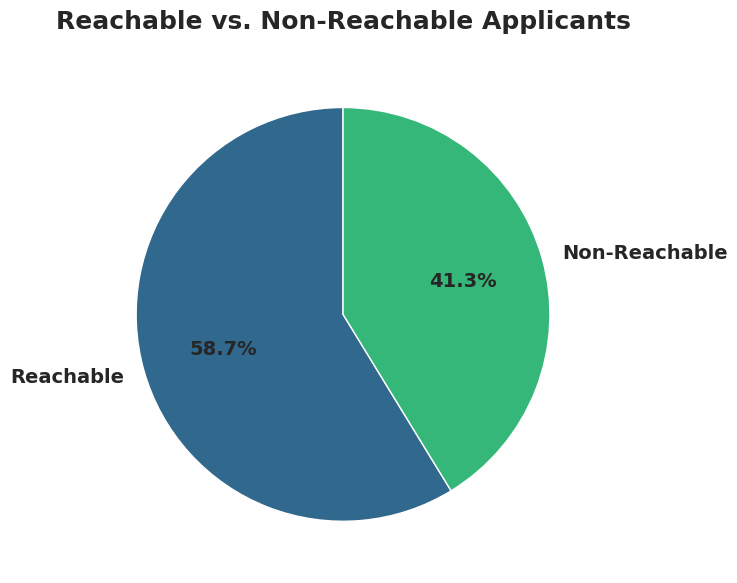

In [ ]:
total_applicants = df['App ID'].nunique()
total_calls_made = len(df)
reachable_leads = df[df['Call_Status'] == 'Connected']['App ID'].nunique()
interested_enrolled = df[df['Remarks_Category'] == 'Enrolled']['App ID'].nunique()

# Reachability Percentage
reachability_pct = (reachable_leads / total_applicants) * 100

print(f"Total Unique Applicants: {total_applicants}")
print(f"Total Calls Made: {total_calls_made}")
print(f"Total Reachable Leads (Connected): {reachable_leads}")
print(f"Total Enrolled Students: {interested_enrolled}")
print(f"Reachability Rate: {reachability_pct:.2f}%")

print(f"\nInsight: Out of {total_applicants} applicants, only {reachability_pct:.2f}% are actually reachable.\n")

############ REACHABLE vs NON-REACHABLE #############
non_reachable = total_applicants - reachable_leads
pie_values = [reachable_leads, non_reachable]
pie_labels = ['Reachable', 'Non-Reachable']


plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')

colors = sns.color_palette('viridis', 2)

plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90,
        colors=colors, textprops={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Reachable vs. Non-Reachable Applicants', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### **DUPLICATES vs NON-DUPLICATES**

Total Applicants - 33069
Total Unique Applicants - 15114


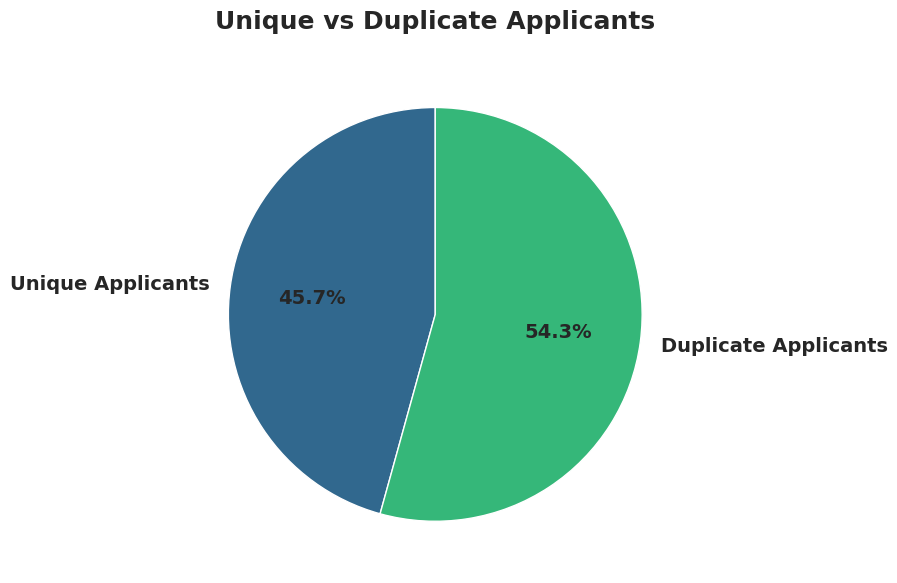

In [ ]:
T = df['App ID'].count()
T_unique = df['App ID'].nunique()
print(f'Total Applicants - {T}')
print(f'Total Unique Applicants - {T_unique}')


# Your logic
T = df['App ID'].count()
T_unique = df['App ID'].nunique()

pie_values = [T_unique, T - T_unique]
pie_labels = ['Unique Applicants', 'Duplicate Applicants']


plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')

colors = sns.color_palette('viridis', 2)

plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=90,
        colors=colors, textprops={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Unique vs Duplicate Applicants', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### **DISTRIBUTIONS**

DISTRIBUTIONS

Call_Status
Not Connected    69.35%
Connected        30.65%
Name: count, dtype: object

Escalation_Required
No     97.74%
Yes     2.26%
Name: count, dtype: object

Admission_Category
Post Admission    78.61%
Pre Admission     21.39%
Name: count, dtype: object


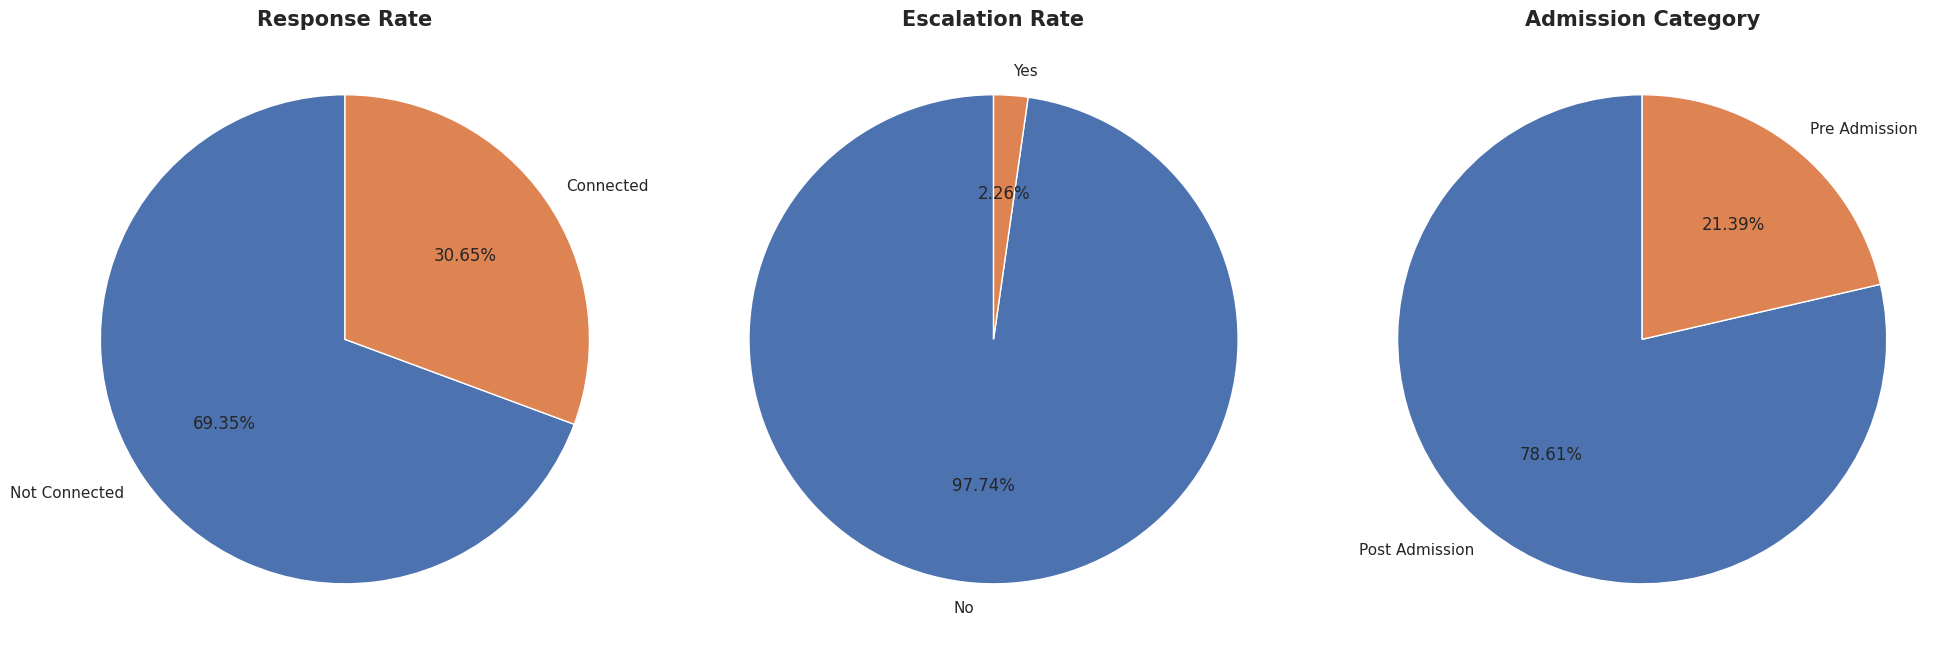

In [ ]:
print("DISTRIBUTIONS\n")
## CALL STATUS DISTRIBUTION
call_status = df["Call_Status"].value_counts()
response_rate = ((call_status/ len(df)) * 100).round(2)
print(response_rate.astype(str) + '%')

## ESCALATION RATE DISTRIBUTION
escalation_required = df['Escalation_Required'].value_counts()
escalation_rate = ((escalation_required/ len(df))*100).round(2)
print(f"\n{escalation_rate.astype(str) + '%'}")

## ADMISSION CATEGORY DISTRIBUTION
admission_category = df['Admission_Category'].value_counts()
admission_rate = ((admission_category/ len(df))*100).round(2)
print(f"\n{admission_rate.astype(str) + '%'}")


distributions = {
    "Response Rate": response_rate,
    "Escalation Rate": escalation_rate,
    "Admission Category": admission_rate
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, (title, data) in enumerate(distributions.items()):
    axes[i].pie(data, labels=data.index, autopct='%.2f%%', startangle= 90)
    axes[i].set_title(title, fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### **Remarks Category - Distribution**

In [ ]:
print("DISTRIBUTIONS\n")

## REMARKS CATEGORY DISTRIBUTION
remarks_category = df['Remarks_Category'].value_counts()
remarks_category_rate = ((remarks_category/ len(df))*100).round(2)
print(f"\n{remarks_category_rate.astype(str) + '%'}")



DISTRIBUTIONS


Remarks_Category
No Remarks                 72.78%
Application Required       12.07%
Not Interested              5.02%
Interested                  3.09%
Still Making A Decision     2.65%
Application Completed       2.37%
Enroll Soon                 0.99%
Enrolled                    0.31%
Needs Assistance            0.31%
Duplicate                   0.25%
Wrong Number                0.15%
Name: count, dtype: object


## **Remarks Category - Distribution**

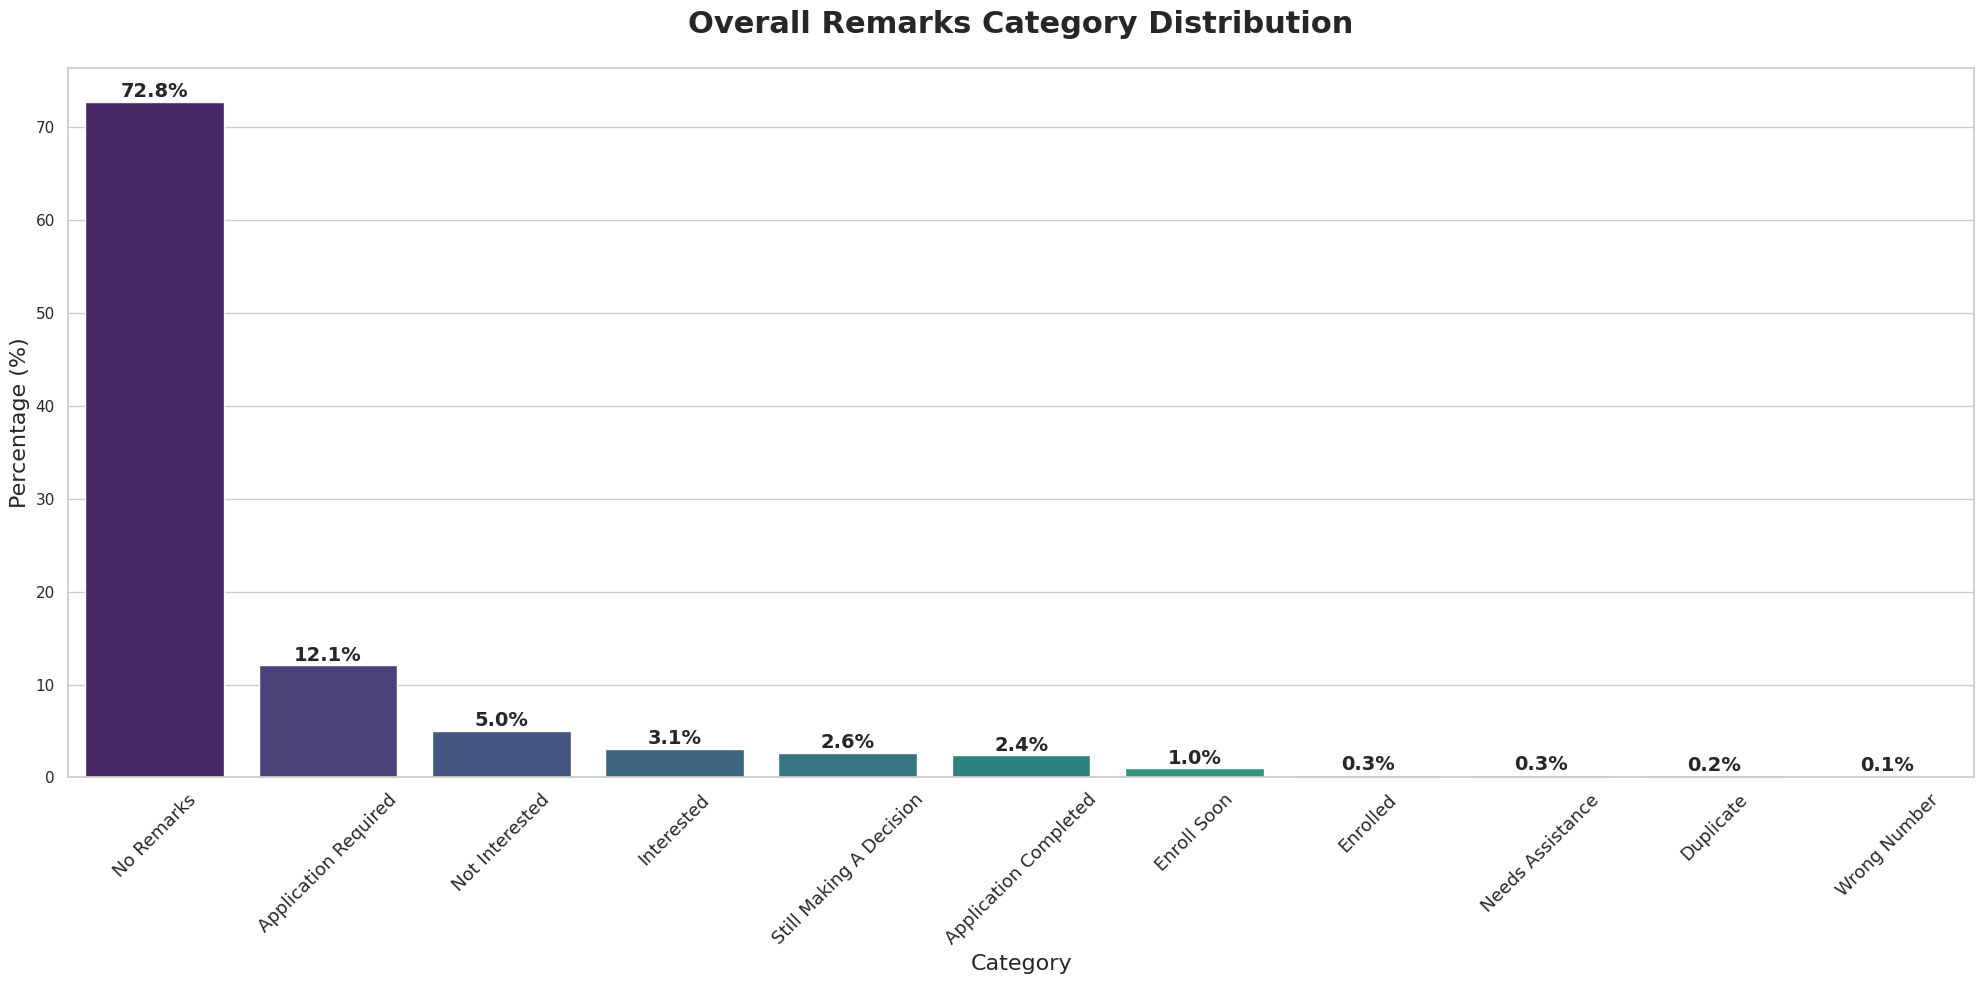

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


fig, ax = plt.subplots(figsize=(20, 10))

sns.barplot(x=remarks_category_rate.index,
            y=remarks_category_rate.values,
            ax=ax,
            palette="viridis",
            hue=remarks_category_rate.index,
            legend=False)


for index, value in enumerate(remarks_category_rate.values):
    ax.text(index, value + 0.5, f'{value:.1f}%',
            ha='center', fontweight='bold', fontsize=14)


ax.set_title("Overall Remarks Category Distribution", fontsize=22, fontweight='bold', pad=25)
ax.set_ylabel("Percentage (%)", fontsize=16)
ax.set_xlabel("Category", fontsize=16)
ax.tick_params(axis='x', rotation=45, labelsize=13)

plt.tight_layout()
plt.show()

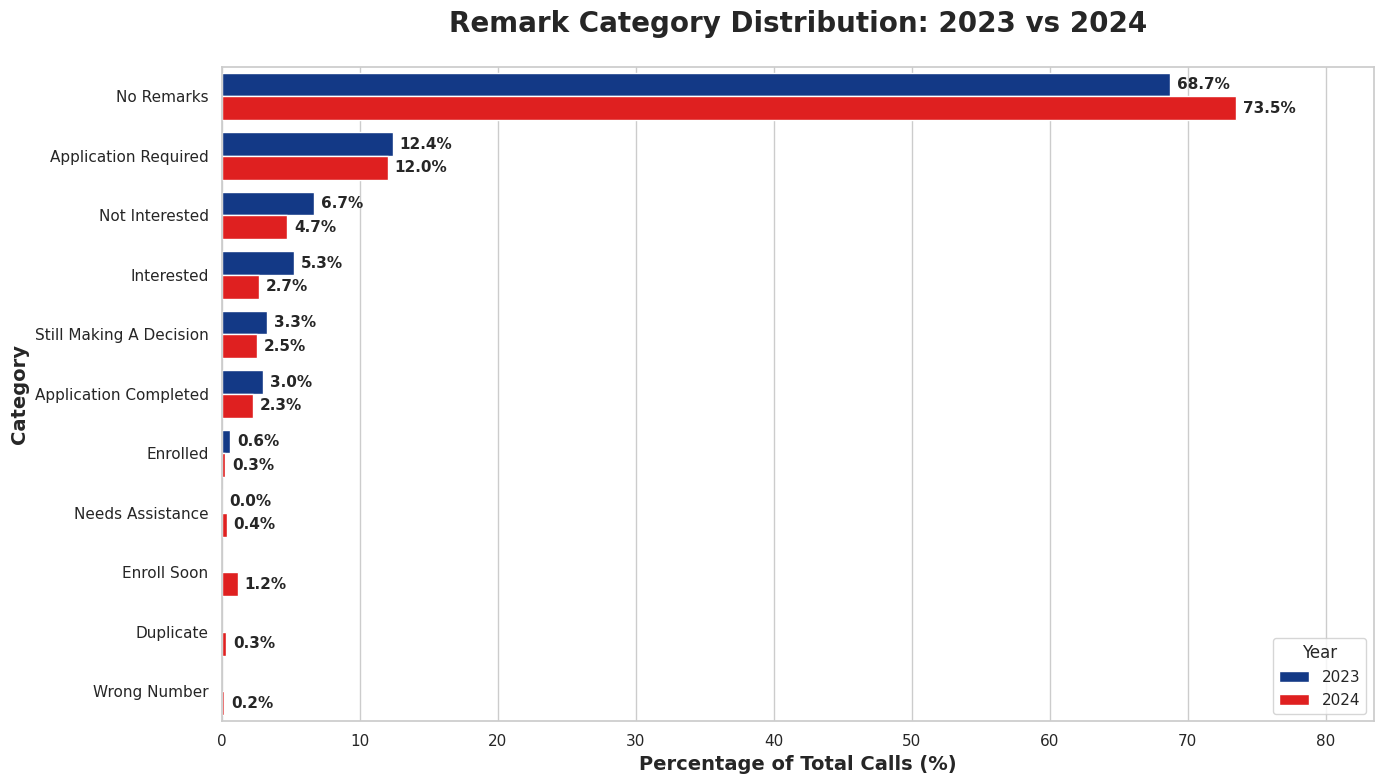

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Data
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])
df['Year'] = df['Outreach_Call'].dt.year

# Filter for relevant years
df_filtered = df[df['Year'].isin([2023, 2024])].copy()

# 2. Calculate Percentages by Year and Category
# We use 'Remarks_Category' as it is the cleaned version of 'Remarks'
dist_data = df_filtered.groupby(['Year', 'Remarks_Category']).size().reset_index(name='count')

# Normalize to show percentage within each year
year_totals = dist_data.groupby('Year')['count'].transform('sum')
dist_data['percentage'] = (dist_data['count'] / year_totals) * 100

# Sort by percentage for a cleaner "Big Picture" look
dist_data = dist_data.sort_values(['Year', 'percentage'], ascending=[True, False])

# 3. Plotting (Horizontal Bar Chart for better readability)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Blue for 2023, Red for 2024 to match your trend line chart
custom_palette = {2023: "#003399", 2024: "#FF0000"}

ax = sns.barplot(
    data=dist_data,
    y='Remarks_Category', # Vertical categories
    x='percentage',       # Horizontal bars
    hue='Year',
    palette=custom_palette
)

# 4. Add Value Labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%',
                    (width + 0.5, p.get_y() + p.get_height() / 2.),
                    va='center', fontsize=11, fontweight='bold')

# 5. Styling
ax.set_title("Remark Category Distribution: 2023 vs 2024", fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel("Percentage of Total Calls (%)", fontsize=14, fontweight='bold')
ax.set_ylabel("Category", fontsize=14, fontweight='bold')
ax.set_xlim(0, dist_data['percentage'].max() + 10) # Add space for labels

plt.tight_layout()
plt.show()

# **PART 2: OPERATIONAL PERFORMANCE ANALYSIS**



### **MONTHLY OUTREACH TREND**

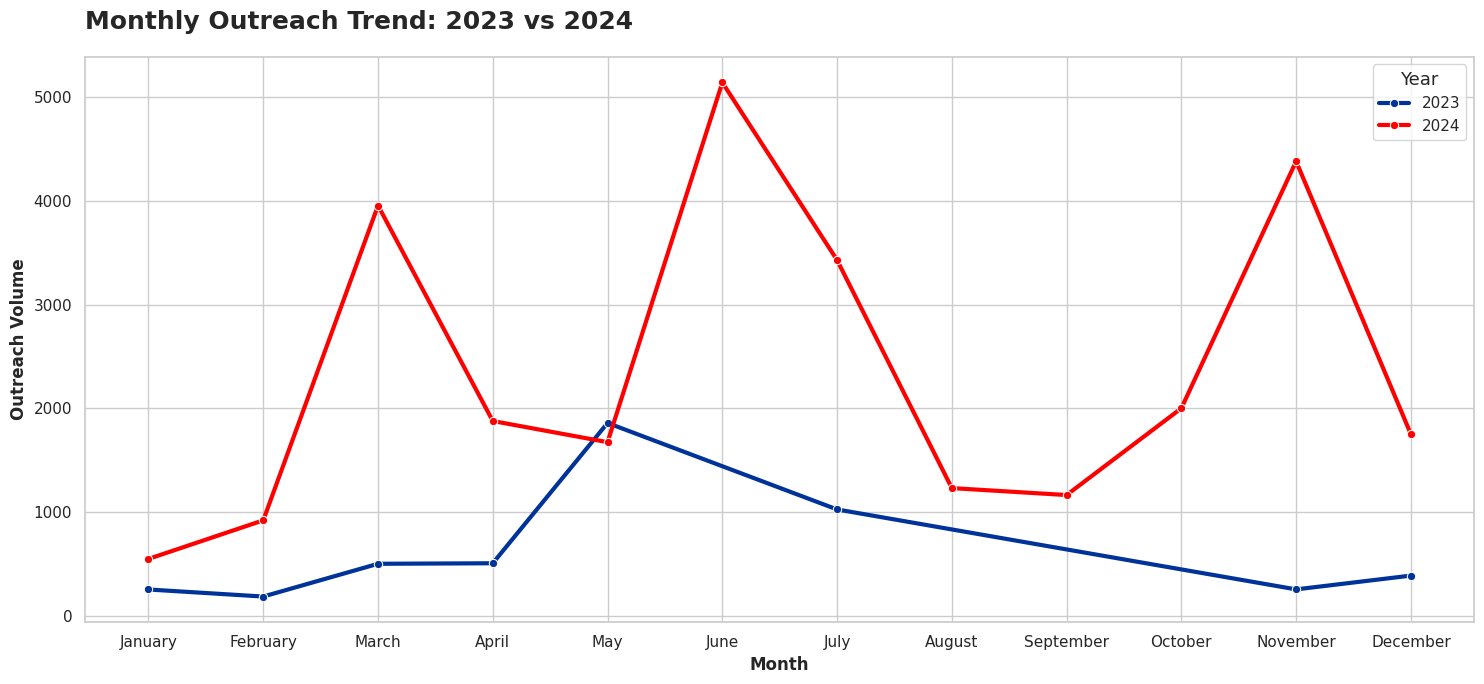

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert Outreach_Call to datetime objects
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])

# 2. Extract Year and Month Name
df['Year'] = df['Outreach_Call'].dt.year
df['Month_Name'] = df['Outreach_Call'].dt.month_name()

# 3. Aggregate data by Year and Month
# We also extract month number to ensure the X-axis sorts Jan -> Dec
df['Month_Num'] = df['Outreach_Call'].dt.month
monthly_trend = df.groupby(['Year', 'Month_Num', 'Month_Name']).size().reset_index(name='Outreach_Volume')

# 4. Filter for only 2023 and 2024
trend_comparison = monthly_trend[monthly_trend['Year'].isin([2023, 2024])].sort_values('Month_Num')

# 5. Charting
plt.figure(figsize=(15, 7))
sns.set_theme(style='whitegrid')

# Define custom palette: Blue for 2023, Red for 2024
custom_palette = {2023: "#003399", 2024: "#FF0000"}

sns.lineplot(
    data=trend_comparison,
    x='Month_Name',
    y='Outreach_Volume',
    hue='Year',
    palette=custom_palette,
    marker='o',
    linewidth=3
)

# 6. Styling
plt.title('Monthly Outreach Trend: 2023 vs 2024', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Outreach Volume', fontsize=12, fontweight='bold')

# Legend Customization
plt.legend(title='Year', title_fontsize='13', fontsize='11', loc='upper right')

plt.tight_layout()
plt.show()

### **MONTHLY ENROLLMENT TREND**





/tmp/ipython-input-511/1566144985.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  enrolled_trend = enrolled_df.groupby(['Year', 'Month_Name']).size().reset_index(name='Enrollment_Volume')


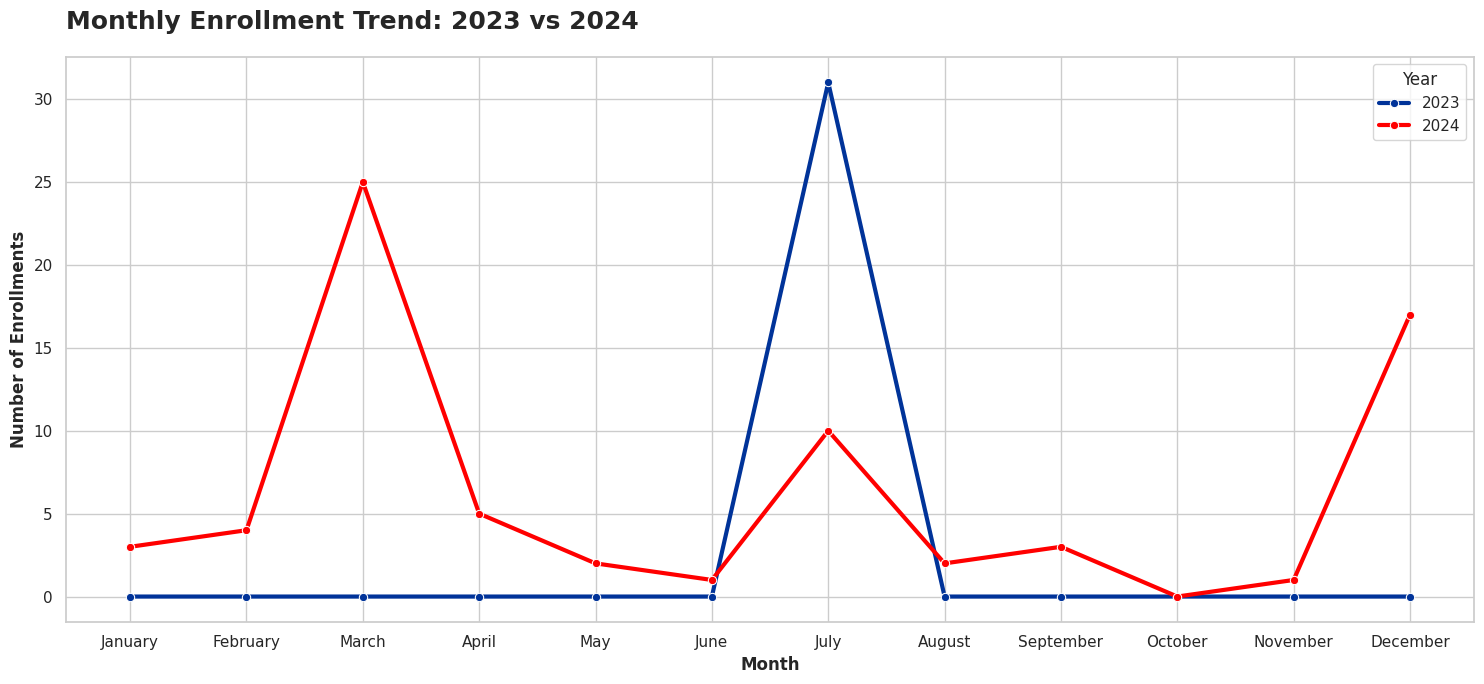

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for Enrolled only
enrolled_df = df[df['Remarks_Category'] == 'Enrolled'].copy()
enrolled_df['Outreach_Call'] = pd.to_datetime(enrolled_df['Outreach_Call'])

# 2. Extract Year and Month Name
enrolled_df['Year'] = enrolled_df['Outreach_Call'].dt.year
enrolled_df['Month_Name'] = enrolled_df['Outreach_Call'].dt.month_name()

# 3. Create a categorical type for months to force the correct order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
enrolled_df['Month_Name'] = pd.Categorical(enrolled_df['Month_Name'], categories=month_order, ordered=True)

# 4. Aggregate and SORT by that month order
enrolled_trend = enrolled_df.groupby(['Year', 'Month_Name']).size().reset_index(name='Enrollment_Volume')
enrolled_trend = enrolled_trend.sort_values(['Year', 'Month_Name'])

# 5. Charting
plt.figure(figsize=(15, 7))
sns.set_theme(style='whitegrid')

custom_palette = {2023: "#003399", 2024: "#FF0000"}

# Use lineplot with the sorted data
sns.lineplot(
    data=enrolled_trend,
    x='Month_Name',
    y='Enrollment_Volume',
    hue='Year',
    palette=custom_palette,
    marker='o',
    linewidth=3
)

plt.title('Monthly Enrollment Trend: 2023 vs 2024', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Enrollments', fontsize=12, fontweight='bold')
plt.legend(title='Year')

plt.tight_layout()
plt.show()

### **HOURLY OUTREACH TREND**

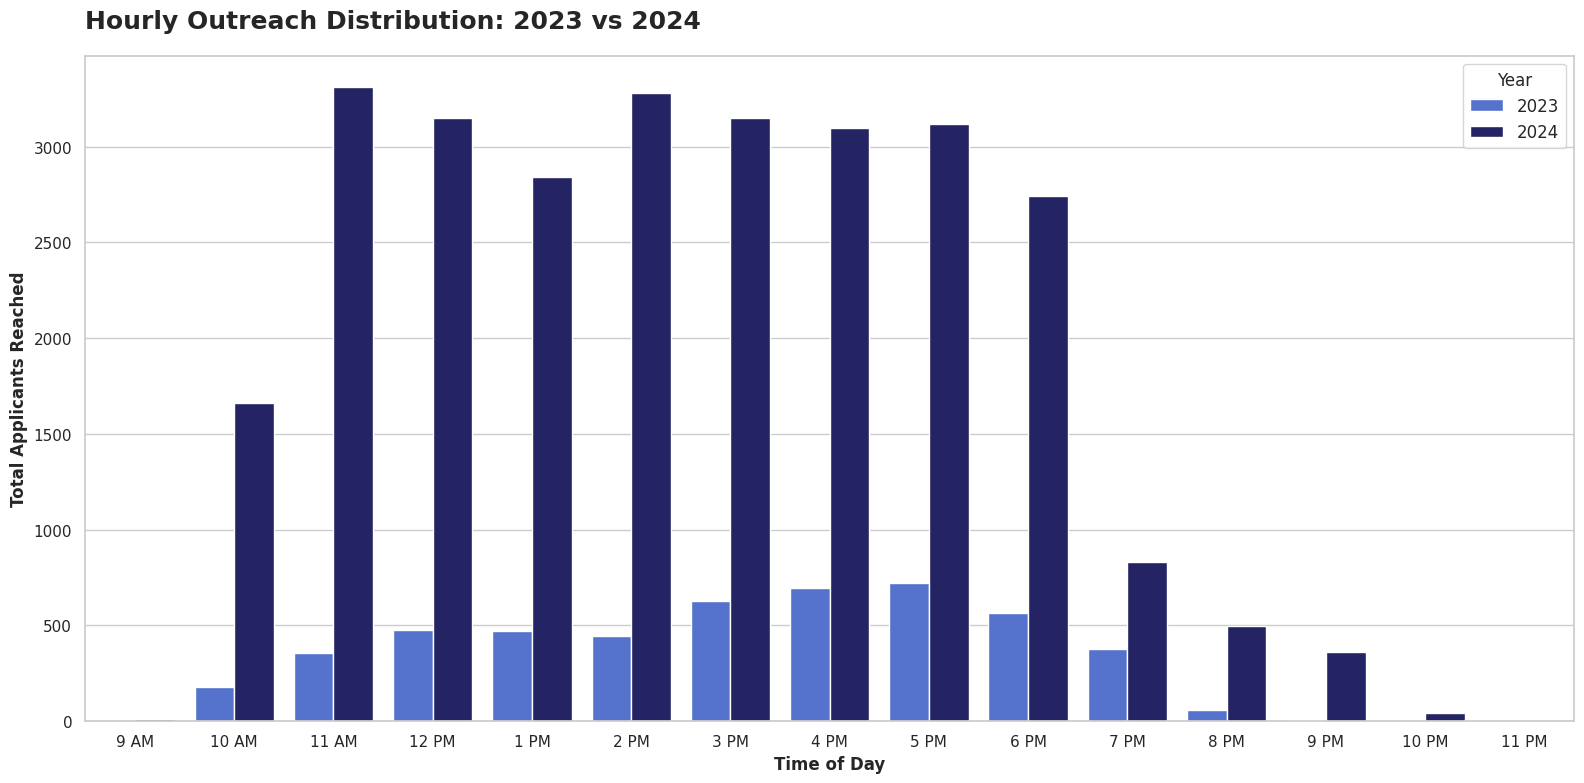

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert to datetime
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])

# 2. Extract Year and 24-Hour integer for sorting
df['Year'] = df['Outreach_Call'].dt.year
df['Hour_24'] = df['Outreach_Call'].dt.hour

# 3. Create a strict list of hours (9 AM to 11 PM)
# 9 to 23 covers 9 AM (9) through 11 PM (23)
hour_range = list(range(9, 24))

# Generate the labels for these hours (e.g., 9 AM, 10 AM...)
time_labels = [pd.to_datetime(str(h), format='%H').strftime('%I %p').lstrip('0') for h in hour_range]

# 4. Filter data for these hours and years 2023/2024
filtered_df = df[df['Hour_24'].isin(hour_range) & df['Year'].isin([2023, 2024])].copy()

# 5. Group by Year and Hour
hourly_trend = filtered_df.groupby(['Year', 'Hour_24']).size().reset_index(name='Total_Applicants')

# 6. Map the Time Labels back for the X-axis
hourly_trend['Time_Label'] = hourly_trend['Hour_24'].apply(lambda x: pd.to_datetime(str(x), format='%H').strftime('%I %p').lstrip('0'))

# 7. Charting
plt.figure(figsize=(16, 8))
sns.set_theme(style='whitegrid')

# Royal Blue (2023) and Midnight Blue (2024)
custom_palette = {2023: "#4169E1", 2024: "#191970"}

# Use categorical type on Time_Label to FORCE the order on the X-axis
hourly_trend['Time_Label'] = pd.Categorical(hourly_trend['Time_Label'], categories=time_labels, ordered=True)
hourly_trend = hourly_trend.sort_values(['Year', 'Hour_24'])

# --- CHANGE FROM LINEPLOT TO BARPLOT ---
sns.barplot(
    data=hourly_trend,
    x='Time_Label',
    y='Total_Applicants',
    hue='Year',
    palette=custom_palette
)

plt.legend(title='Year', loc='upper right', fontsize=12)

# 8. Styling
plt.title('Hourly Outreach Distribution: 2023 vs 2024', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('Time of Day', fontsize=12, fontweight='bold')
plt.ylabel('Total Applicants Reached', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### **HOURLY ENROLLMENT TREND**

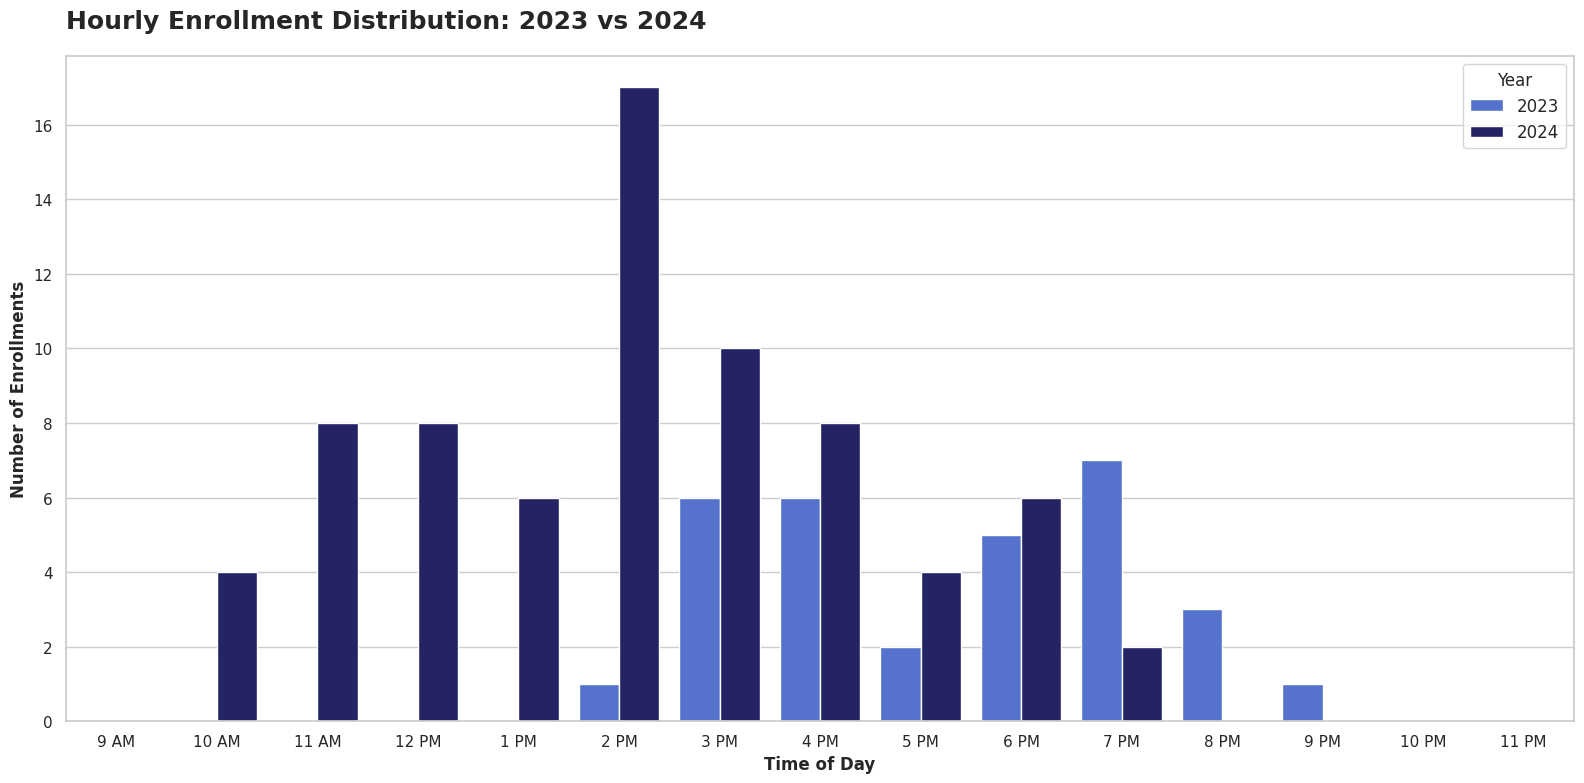

In [ ]:
# 'Enrolled' category
# This ensures we only analyze successful enrollments
enrolled_df = df[df['Remarks_Category'] == 'Enrolled'].copy()

# Convert to datetime
enrolled_df['Outreach_Call'] = pd.to_datetime(enrolled_df['Outreach_Call'])

# Extract Year and 24-Hour integer for sorting
enrolled_df['Year'] = enrolled_df['Outreach_Call'].dt.year
enrolled_df['Hour_24'] = enrolled_df['Outreach_Call'].dt.hour

# Create a strict list of hours (9 AM to 11 PM)
hour_range = list(range(9, 24))
time_labels = [pd.to_datetime(str(h), format='%H').strftime('%I %p').lstrip('0') for h in hour_range]

# Filter for these hours and years 2023/2024
filtered_enrolled = enrolled_df[enrolled_df['Hour_24'].isin(hour_range) & enrolled_df['Year'].isin([2023, 2024])].copy()

# Group by Year and Hour
hourly_enrolled = filtered_enrolled.groupby(['Year', 'Hour_24']).size().reset_index(name='Enrolled_Count')

# Map the Time Labels and FORCE the order
hourly_enrolled['Time_Label'] = hourly_enrolled['Hour_24'].apply(lambda x: pd.to_datetime(str(x), format='%H').strftime('%I %p').lstrip('0'))
hourly_enrolled['Time_Label'] = pd.Categorical(hourly_enrolled['Time_Label'], categories=time_labels, ordered=True)
hourly_enrolled = hourly_enrolled.sort_values(['Year', 'Hour_24'])

# Charting
plt.figure(figsize=(16, 8))
sns.set_theme(style='whitegrid')

# Royal Blue (2023) and Midnight Blue (2024)
custom_palette = {2023: "#4169E1", 2024: "#191970"}

sns.barplot(data=hourly_enrolled, x='Time_Label', y='Enrolled_Count', hue='Year', palette=custom_palette)

# Styling & Legend
plt.title('Hourly Enrollment Distribution: 2023 vs 2024', fontsize=18, fontweight='bold', loc='left', pad=20)
plt.xlabel('Time of Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Enrollments', fontsize=12, fontweight='bold')

# Legend: Handled automatically to match colors to Year
plt.legend(title='Year', loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## **Total Vs Unique Applicants - Pre & post admission 2023 vs 2024**

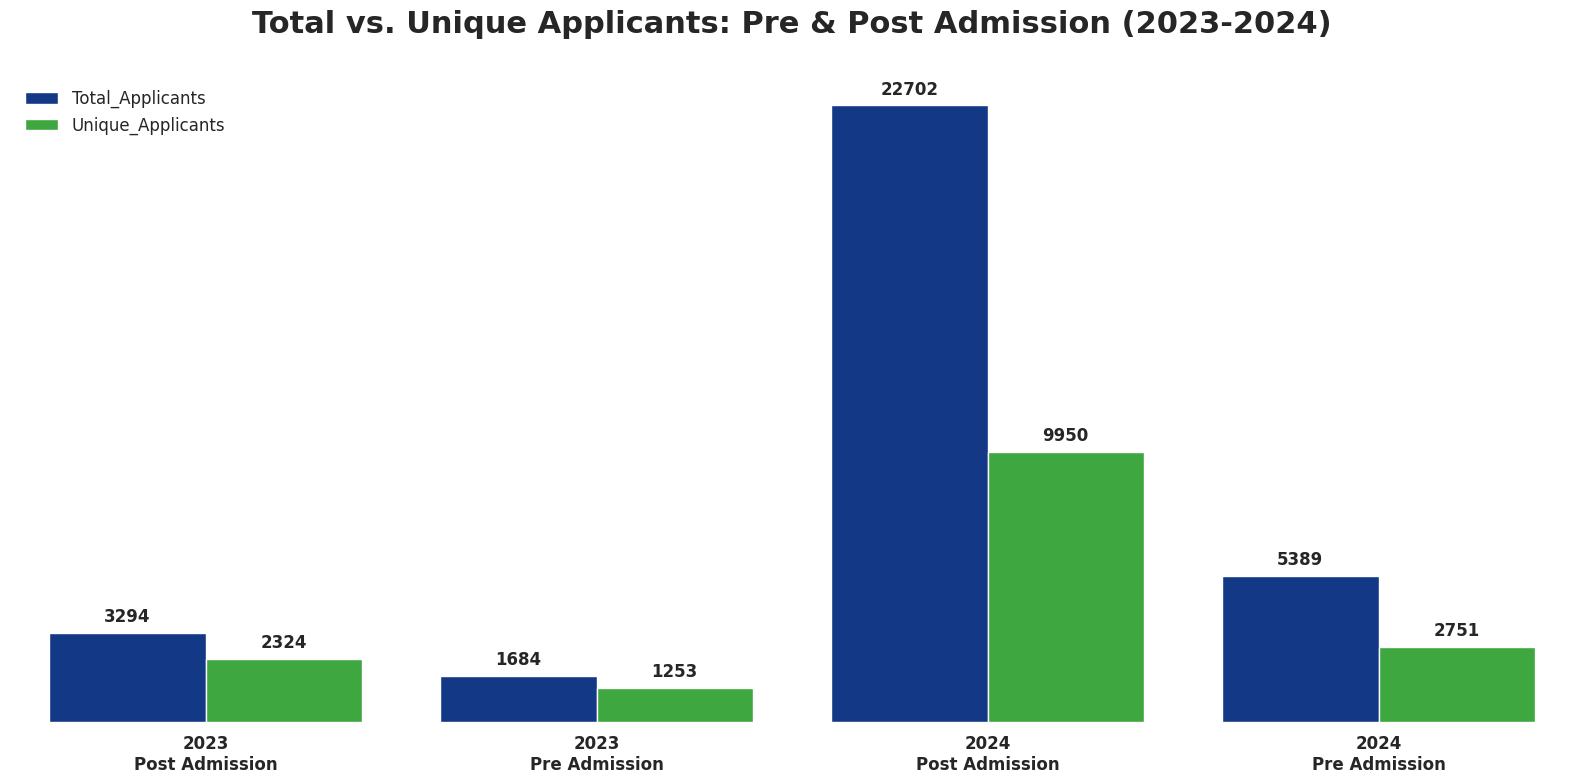

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])
df['Year'] = df['Outreach_Call'].dt.year

# 2. Aggregate by Year and Admission Category
# Calculating both Total (count) and Unique (nunique)
category_perf = df[df['Year'].isin([2023, 2024])].groupby(['Year', 'Admission_Category']).agg(
    Total_Applicants=('App ID', 'count'),
    Unique_Applicants=('App ID', 'nunique')
).reset_index()

# 3. Melt the data for clustered plotting
melted_df = category_perf.melt(id_vars=['Year', 'Admission_Category'],
                               value_vars=['Total_Applicants', 'Unique_Applicants'],
                               var_name='Metric',
                               value_name='Count')

# Create a combined label for the X-axis (e.g., "2023 - Post Admission")
melted_df['Year_Category'] = melted_df['Year'].astype(str) + "\n" + melted_df['Admission_Category']

# 4. Plotting
plt.figure(figsize=(16, 8))
sns.set_style("white")

# Professional Color Palette
palette = {'Total_Applicants': '#003399', 'Unique_Applicants': '#2eb82e'}

ax = sns.barplot(data=melted_df, x='Year_Category', y='Count', hue='Metric', palette=palette)

# 5. Add Value Labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

# 6. Minimalist Styling
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(fontsize=12, fontweight='bold')

# 7. Titles and Legend
plt.title('Total vs. Unique Applicants: Pre & Post Admission (2023-2024)',
          fontsize=22, fontweight='bold', pad=30)
plt.legend(frameon=False, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

## **Enrollment - Pre vs Post Admission**

/tmp/ipython-input-511/1266690768.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


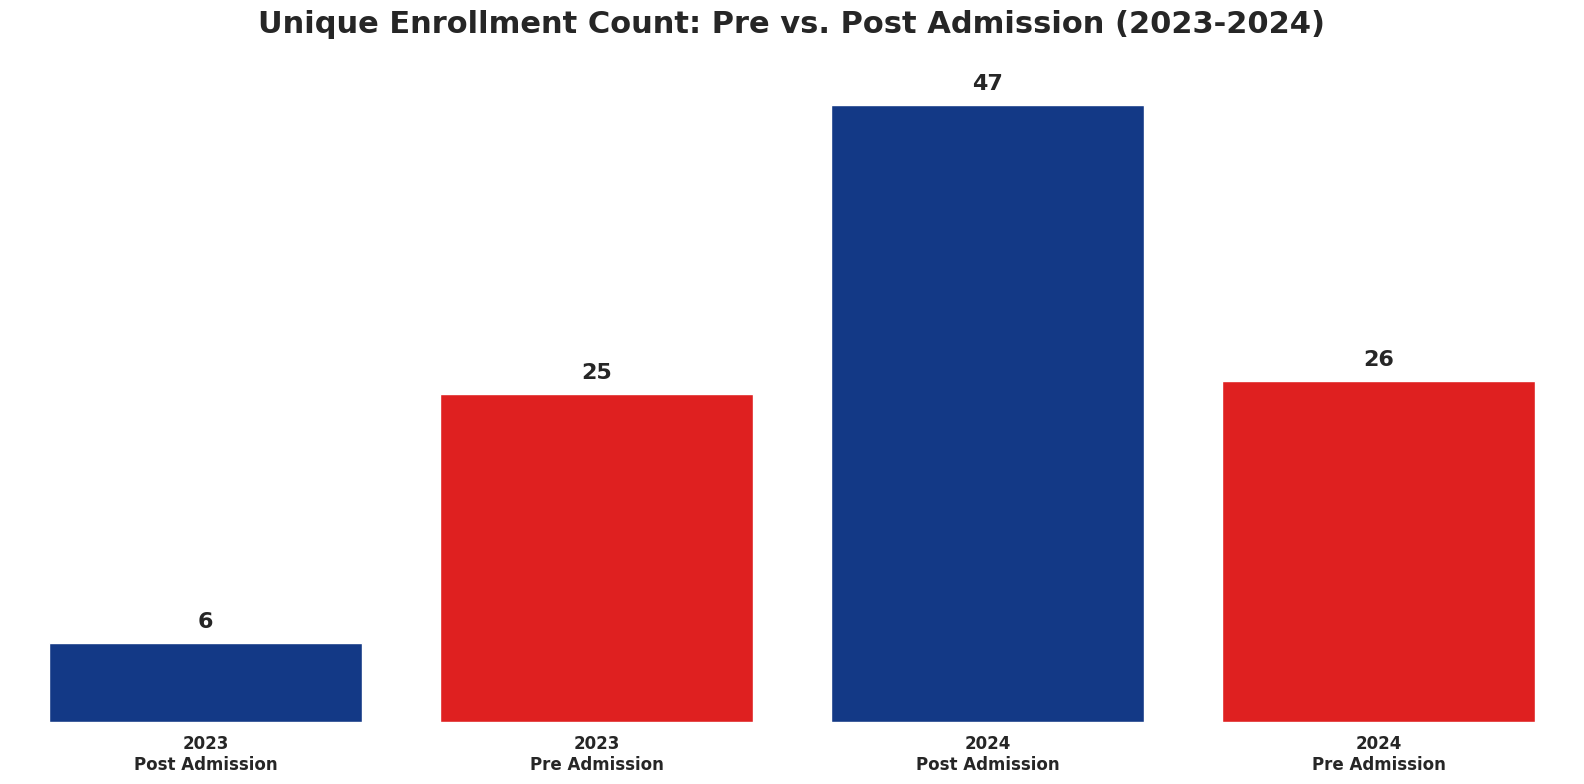

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])
df['Year'] = df['Outreach_Call'].dt.year

# 2. Advanced Aggregation
# We calculate the count of Unique Students who actually enrolled
category_stats = df[df['Year'].isin([2023, 2024])].groupby(['Year', 'Admission_Category']).agg(
    Unique_Enrolled=('App ID', lambda x: df.loc[x.index, 'App ID'][df['Remarks_Category'] == 'Enrolled'].nunique())
).reset_index()

# Create labels for X-axis
category_stats['Year_Category'] = category_stats['Year'].astype(str) + "\n" + category_stats['Admission_Category']

# 3. Plotting
plt.figure(figsize=(16, 8))
sns.set_style("white")

# Plotting the raw Unique Enrolled numbers
ax = sns.barplot(
    data=category_stats,
    x='Year_Category',
    y='Unique_Enrolled',
    palette=['#003399', '#FF0000', '#003399', '#FF0000']
)

# 4. Add Raw Numbers (Integers) on top of bars
for p in ax.patches:
    height = p.get_height()
    if height >= 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=16, fontweight='bold',
                    xytext=(0, 8), textcoords='offset points')

# 5. Minimalist Styling
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(fontsize=12, fontweight='bold')

# 6. Titles
plt.title('Unique Enrollment Count: Pre vs. Post Admission (2023-2024)',
          fontsize=22, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

# **PART 3: CAMPAIGN & CATEGORY EFFECTIVENESS AUDIT**

---



## **Campaign ID - Call Distribution**

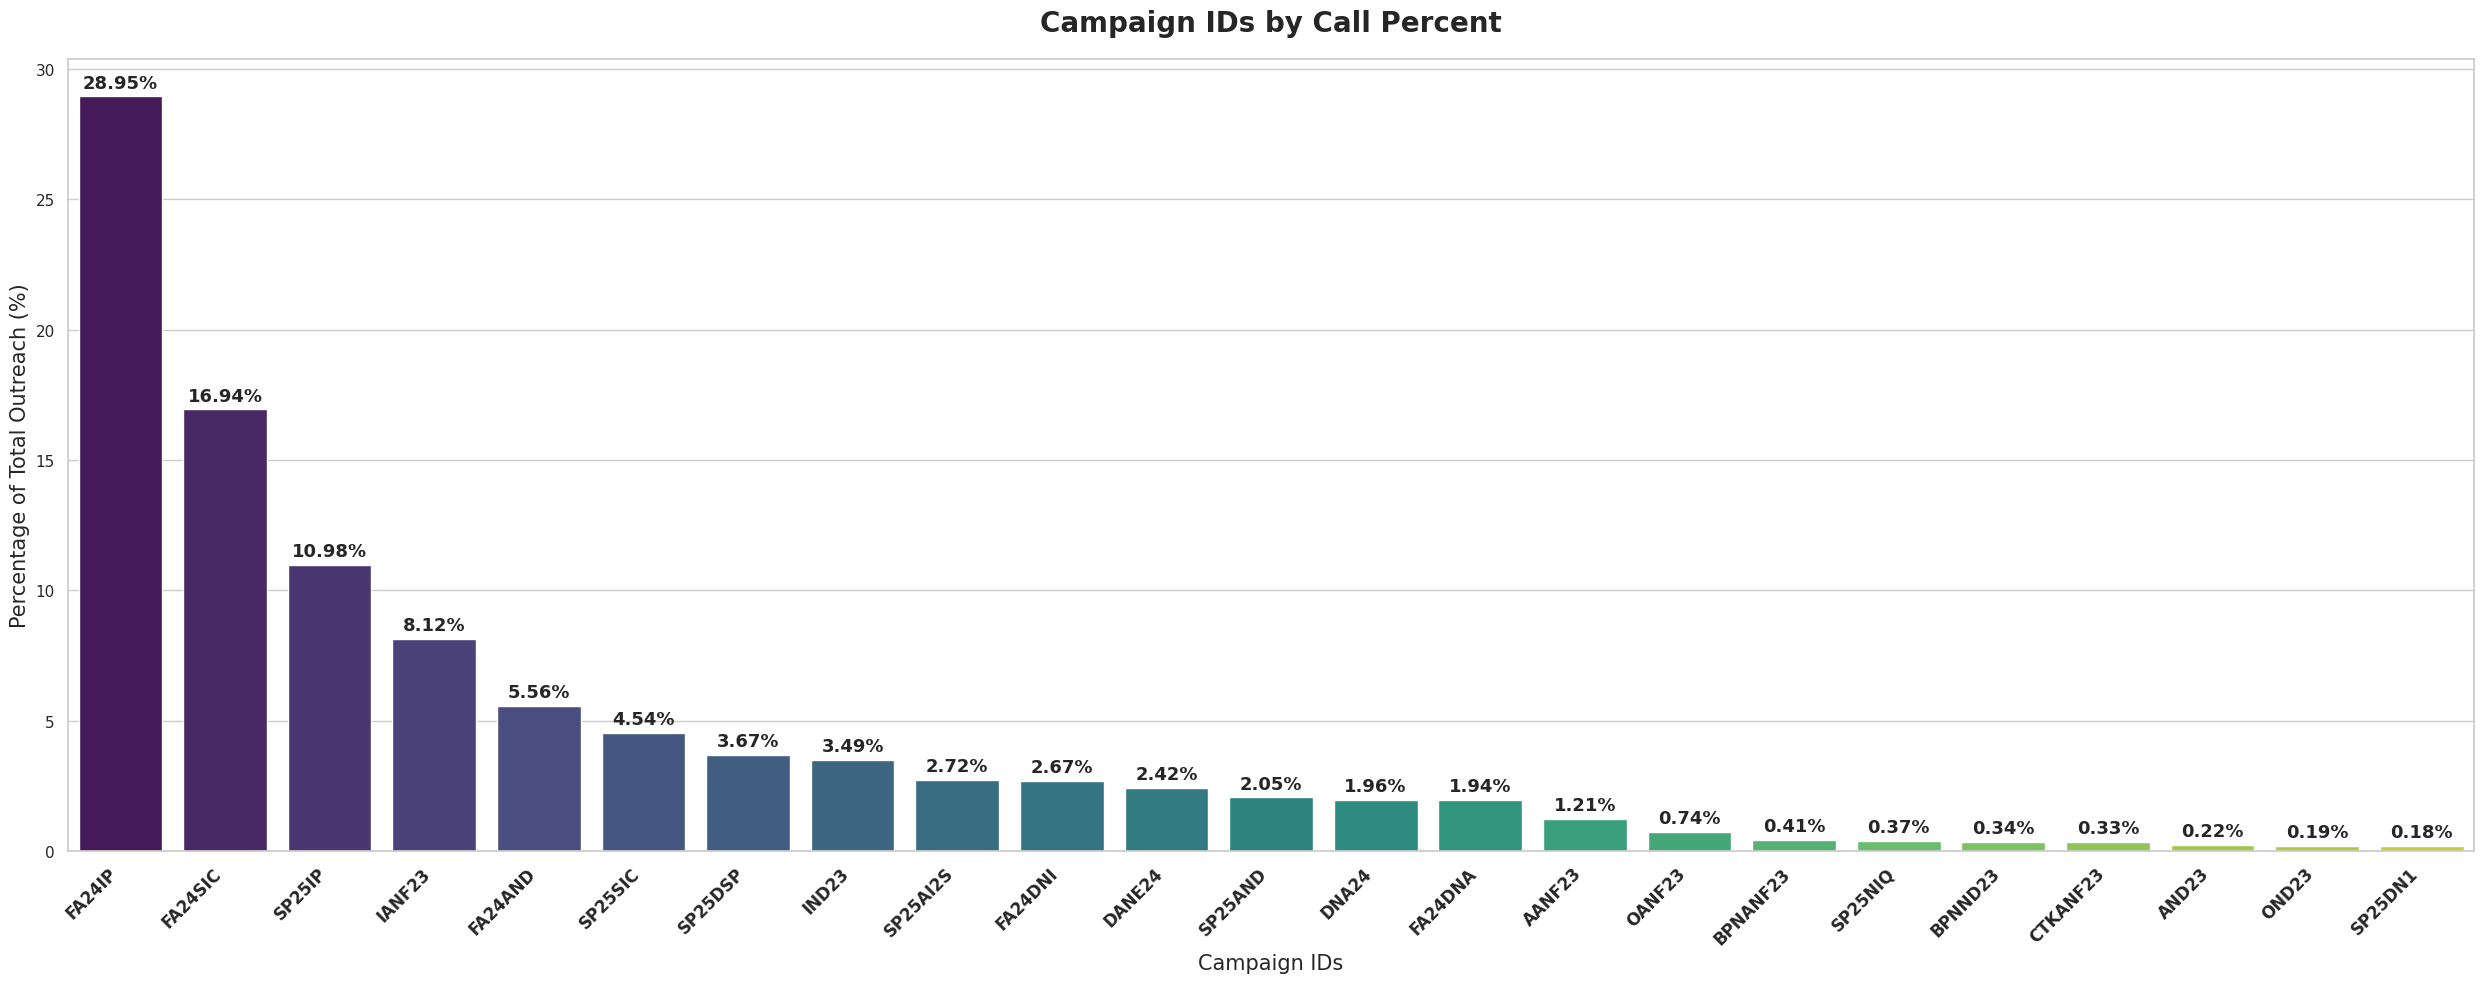

In [ ]:
# CAMPAIGN ID DISTRIBUTION
campaign_id = df['Campaign_ID'].value_counts()
campaign_id_count = ((campaign_id / len(df)) * 100).round(2)

############ CAMPAIGN ID by Call Percent #############
sns.set_theme(style='whitegrid')
plt.figure(figsize=(25, 10))

ax = sns.barplot(data=campaign_id_count.reset_index(), x='Campaign_ID', y='count', palette='viridis', hue='Campaign_ID', legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                xytext=(0, 10),
                textcoords='offset points')


plt.title('Campaign IDs by Call Percent', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Campaign IDs', fontsize=15)
plt.ylabel('Percentage of Total Outreach (%)', fontsize=15)

plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## ***CAMPAIGN ID - ROE (Return on Effort)***

In [ ]:
# Group By Campaign Targeting
campaign_targeting = df.groupby('Campaign_ID').agg(
    Total_Calls=('App ID', 'count'),          # Total outreach effort
    Unique_Students=('App ID', 'nunique'),    # Total leads reached
    Enrolled_Students=('Remarks_Category', lambda x: (x == 'Enrolled').sum()),
    Unique_Enrolled_Students=('App ID', lambda x: df.loc[x.index, 'App ID'][df['Remarks_Category'] == 'Enrolled'].nunique())
)

# Intensity Ratio (How many calls per lead)
campaign_targeting['Intensity_Ratio'] = (campaign_targeting['Total_Calls'] / campaign_targeting['Unique_Students']).round(2)

print(campaign_targeting[campaign_targeting['Total_Calls'] > 1].sort_values(by='Intensity_Ratio', ascending=False).head(10))

             Total_Calls  Unique_Students  Enrolled_Students  \
Campaign_ID                                                    
SP25DSP             1213              366                  0   
SP25AND              678              251                  4   
FA24DNI              882              360                  0   
SP25SIC             1502              623                  0   
SP25AI2S             899              396                 18   
FA24AND             1838              810                 40   
FA24IP              9574             4727                  0   
SP25IP              3631             1813                  1   
FA24DNA              641              340                  1   
FA24SIC             5602             3004                  0   

             Unique_Enrolled_Students  Intensity_Ratio  
Campaign_ID                                             
SP25DSP                             0             3.31  
SP25AND                             4             2.70  
FA2

## **Calculations of Campaign Lead_Conversion and Call efficiency Rate**

In [ ]:
# Lead Conversion Rate (Quality of the Campaign)
# Formula: (Unique Enrolled Students / Total Unique Students) * 100
campaign_targeting['Lead_Conversion_Rate'] = (campaign_targeting['Unique_Enrolled_Students'] / campaign_targeting['Unique_Students'] * 100).round(2)

# Call Efficiency Rate (Return on Effort)
# Formula: (Total Enrollments / Total Calls Made) * 100
campaign_targeting['Call_Efficiency_Rate'] = (campaign_targeting['Enrolled_Students'] / campaign_targeting['Total_Calls'] * 100).round(2)

print("--- Campaign Effectiveness Audit ---")
print(campaign_targeting[campaign_targeting['Total_Calls'] > 5].sort_values(by='Lead_Conversion_Rate', ascending=False).head(10))


--- Campaign Effectiveness Audit ---
             Total_Calls  Unique_Students  Enrolled_Students  \
Campaign_ID                                                    
AND23                 73               59                  6   
FA24AND             1838              810                 40   
SP25AI2S             899              396                 18   
IND23               1153              926                 23   
OND23                 62               42                  1   
SP25AND              678              251                  4   
DANE24               800              565                  7   
BPNND23              114               83                  1   
DNA24                649              484                  2   
FA24DNA              641              340                  1   

             Unique_Enrolled_Students  Intensity_Ratio  Lead_Conversion_Rate  \
Campaign_ID                                                                    
AND23                             

## **Campaign Enrollment Volumn vs Performance Rate**

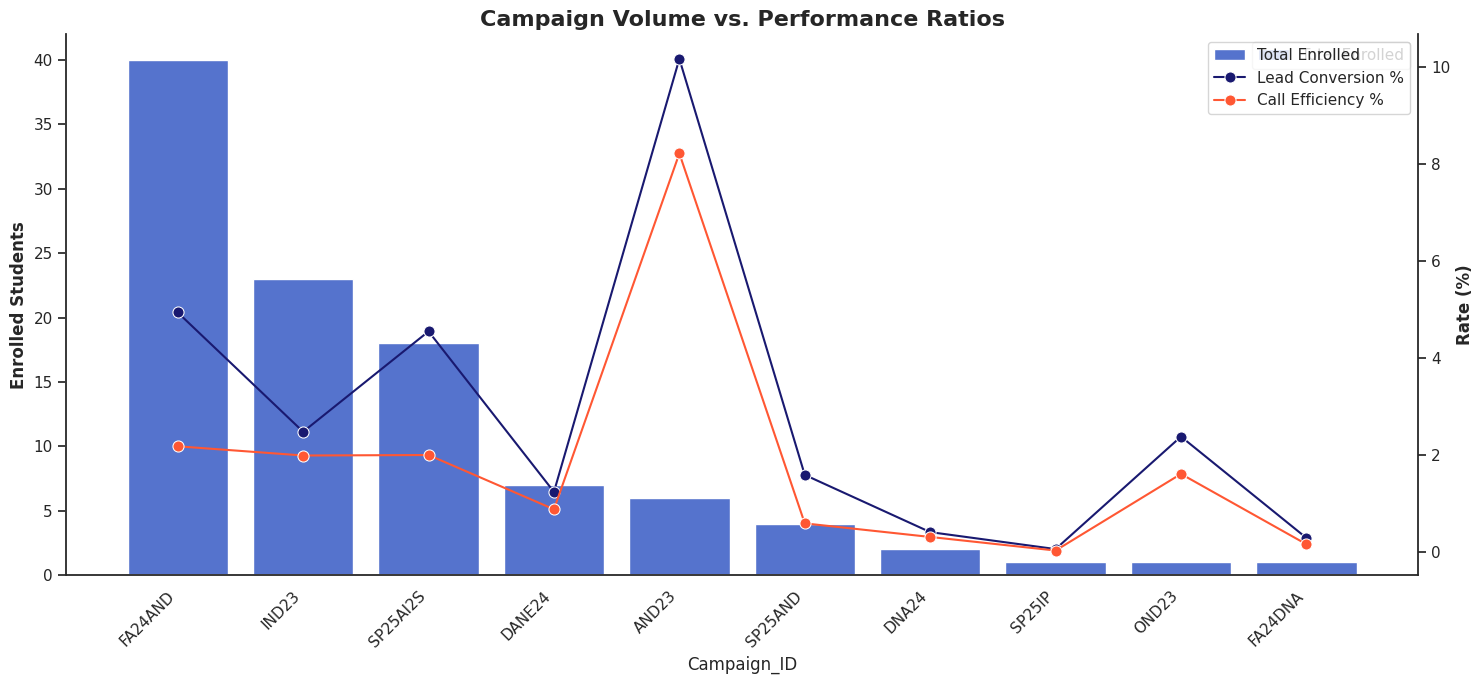

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
top_10_campaign_ID = campaign_targeting.sort_values(by='Enrolled_Students', ascending=False).head(10).reset_index()

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(15, 7))
sns.set_style("white") # Removes all background grids

# --- PLOT 1: ENROLLED STUDENTS (Royal Blue Bars) ---
sns.barplot(data=top_10_campaign_ID, x='Campaign_ID', y='Enrolled_Students',
            color='#4169E1', ax=ax1, label='Total Enrolled')

ax1.set_ylabel('Enrolled Students', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# --- PLOT 2: RATES (Lines on Secondary Axis) ---
ax2 = ax1.twinx()

# Lead Conversion (Midnight Blue)
sns.lineplot(data=top_10_campaign_ID, x='Campaign_ID', y='Lead_Conversion_Rate',
             marker='o', markersize=8, color='#191970', label='Lead Conversion %', ax=ax2)

# Call Efficiency (Orange-Red for contrast)
sns.lineplot(data=top_10_campaign_ID, x='Campaign_ID', y='Call_Efficiency_Rate',
             marker='o', markersize=8, color='#FF5733', label='Call Efficiency %', ax=ax2)

# 3. Clean Up (Removing Grids and Spines)
ax2.set_ylabel('Rate (%)', fontsize=12, fontweight='bold')
sns.despine(right=False, top=True) # Removes top border
ax1.grid(False) # Force grid off
ax2.grid(False) # Force grid off

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Campaign Volume vs. Performance Ratios', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# **PART 4: Market Strategy & Geographic Performance Audit**

---



## **Outreach per Country**

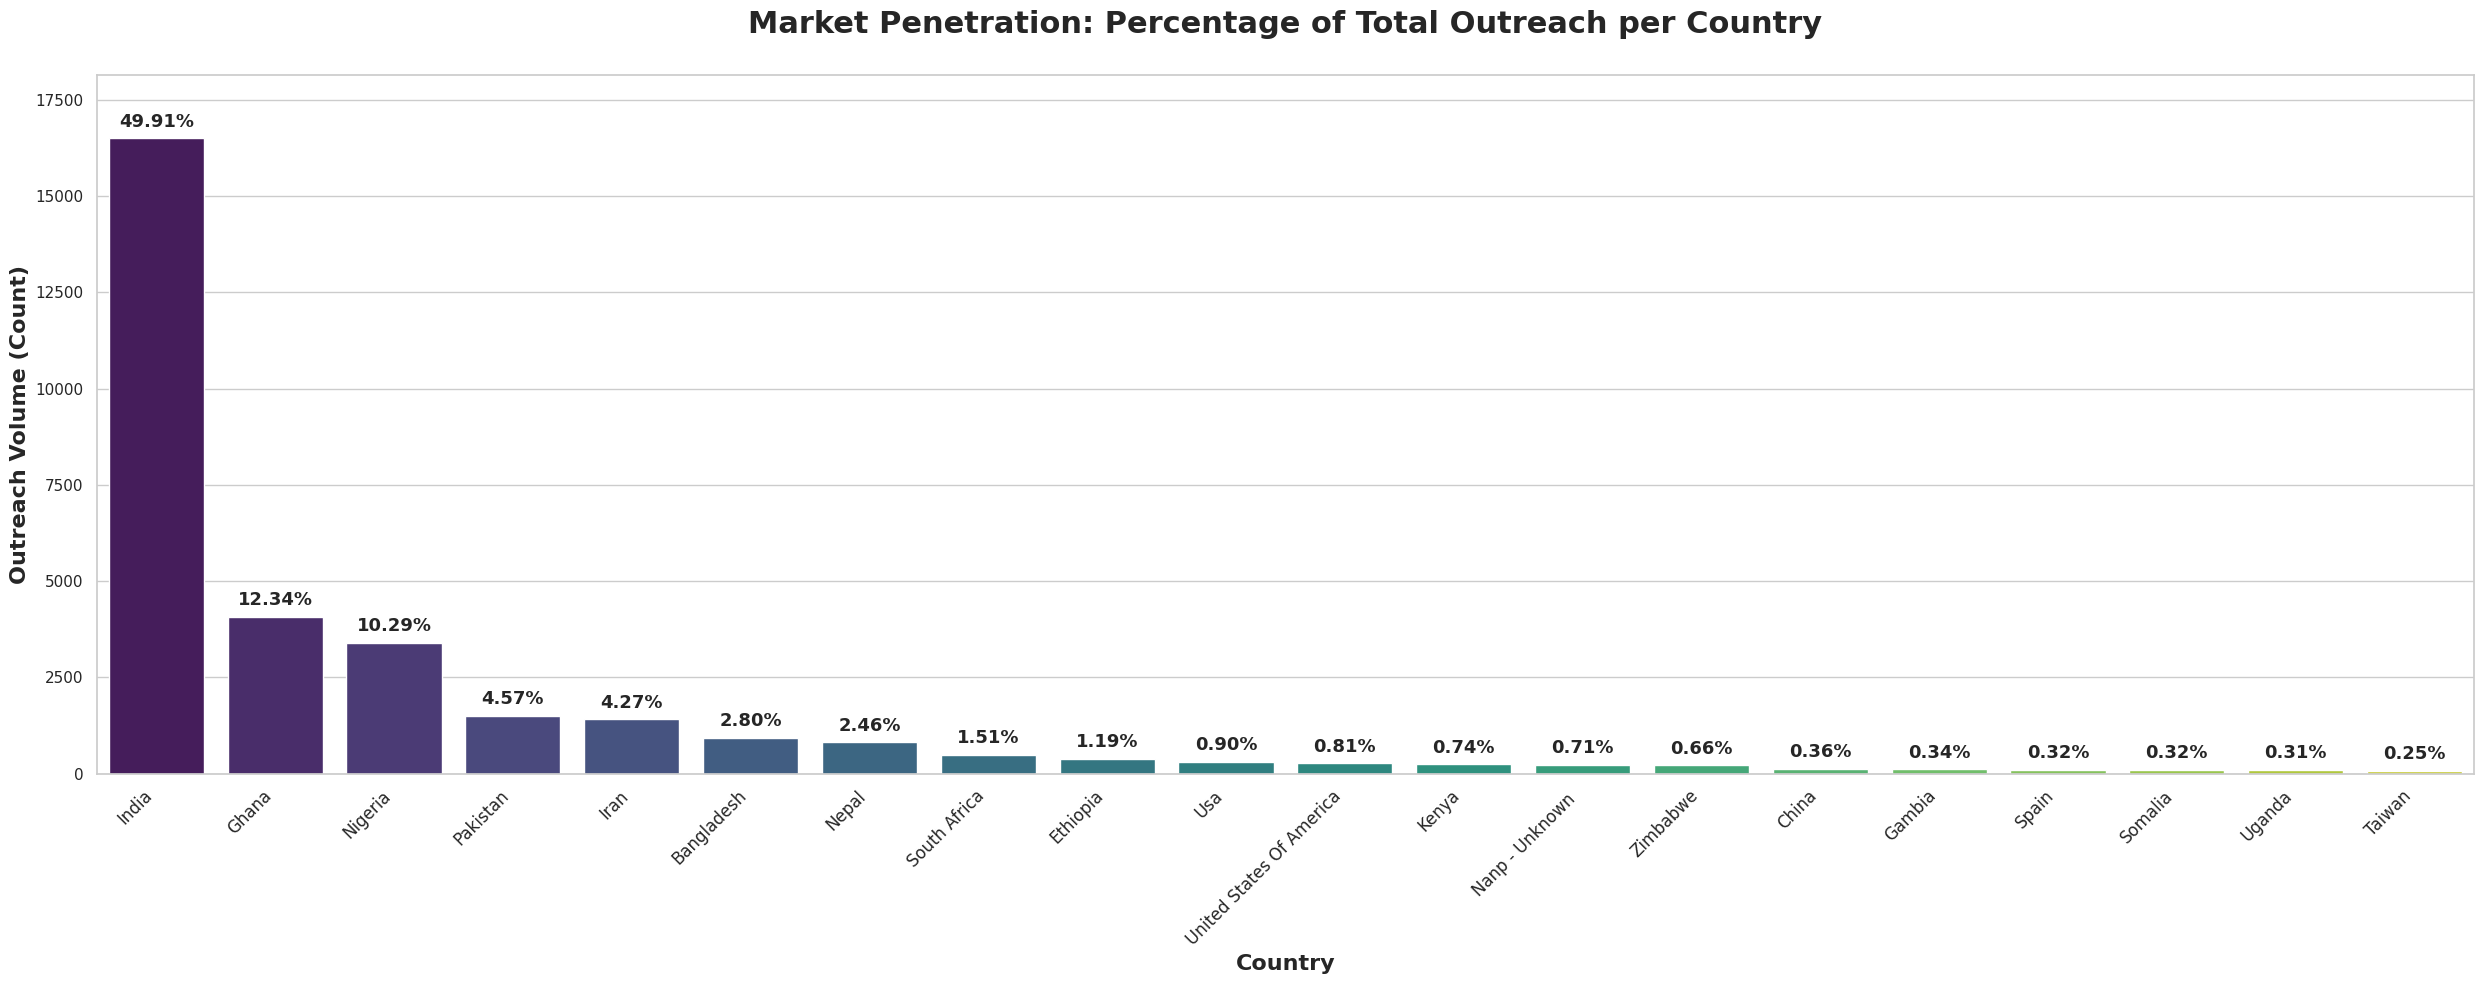

In [ ]:
outreach_country = df['Country'].value_counts().head(20).reset_index()
outreach_country.columns = ['Country', 'count']

total_global_outreach = len(df)


sns.set_theme(style='whitegrid')
plt.figure(figsize=(25, 10))


ax = sns.barplot(data=outreach_country, x='Country', y='count', palette='viridis', hue='Country', legend=False)


for p in ax.patches:
    count = p.get_height()
    percentage = (count / total_global_outreach) * 100
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                xytext=(0, 12),
                textcoords='offset points')

plt.title('Market Penetration: Percentage of Total Outreach per Country', fontsize=22, fontweight='bold', pad=30)
plt.xlabel('Country', fontsize=16, fontweight='bold')
plt.ylabel('Outreach Volume (Count)', fontsize=16, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(0, outreach_country['count'].max() * 1.1)

plt.tight_layout()
plt.show()

## **Total vs Unique Applicants per Country**

              Total_Apps  Unique_Apps
Country                              
India              16506         7395
Ghana               4080         1907
Nigeria             3404         1533
Pakistan            1510          632
Iran                1411          599
Bangladesh           926          283
Nepal                812          315
South Africa         498          383
Ethiopia             392          188
Usa                  299          238


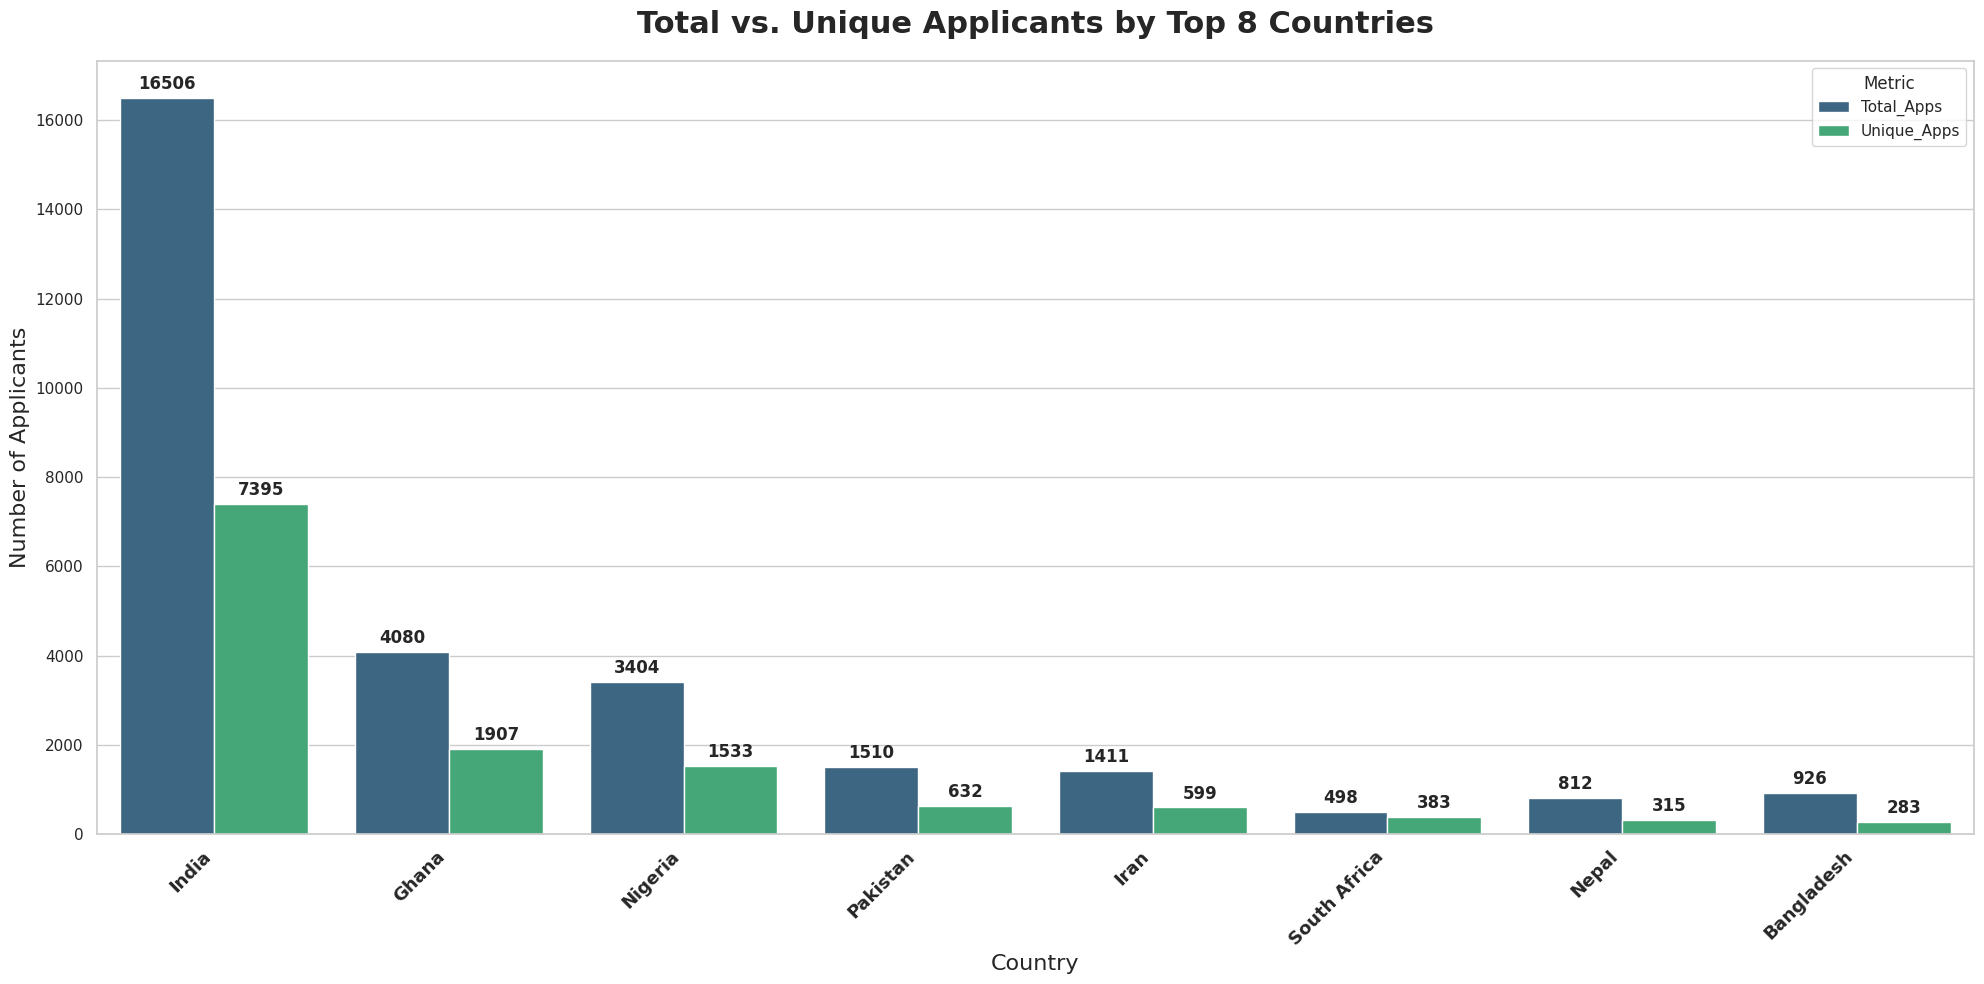

In [ ]:
country_targeting = df.groupby('Country').agg(
    Total_Apps = ('App ID', 'count'),
    Unique_Apps = ('App ID', 'nunique')
)
print(country_targeting.sort_values(by='Total_Apps', ascending=False).head(10))

############# CHART - Country by Total vs Unique Applicants ##############
plot_df = country_targeting.sort_values(by='Unique_Apps', ascending=False).head(8).reset_index()

melted_df = plot_df.melt(id_vars='Country', value_vars=['Total_Apps', 'Unique_Apps'],
                         var_name='Metric', value_name='Count')

plt.figure(figsize=(20, 10))
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=melted_df, x='Country', y='Count', hue='Metric', palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 10),
                    textcoords='offset points')


plt.title('Total vs. Unique Applicants by Top 8 Countries', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Country', fontsize=16)
plt.ylabel('Number of Applicants', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Group by Country to get Total Calls and Unique Students
country_targeting = df.groupby('Country').agg(
    Total_Calls=('App ID', 'count'),          # (including duplicates)
    Unique_Students=('App ID', 'nunique'),    # Count of distinct App IDs
    Enrolled_Students= ('Remarks_Category',lambda x: (x == 'Enrolled').sum()),
    Unique_Enrolled_Students=('App ID', lambda x : df.loc[x.index, 'App ID'][df['Remarks_Category']=='Enrolled'].nunique())
)

# Calculate the Intensity Ratio (Aggressiveness)
country_targeting['Intensity_Ratio'] = (country_targeting['Total_Calls'] / country_targeting['Unique_Students']).round(2)

# Lead Conversion Rate (Quality of the Market)
# Formula: (Unique Enrolled Students / Total Unique Students) * 100
country_targeting['Lead_Conversion_Rate'] = (country_targeting['Unique_Enrolled_Students'] / country_targeting['Unique_Students']) * 100

# Call Efficiency Rate (Return on Effort)
# Formula: (Total Enrollments / Total Calls Made) * 100
country_targeting['Call_Efficiency_Rate'] = (country_targeting['Enrolled_Students'] / country_targeting['Total_Calls']) * 100

# Sort by Total Calls to see the most targeted markets
print(country_targeting[country_targeting['Total_Calls'] > 1].sort_values(by='Lead_Conversion_Rate', ascending=False).head(10))

                          Total_Calls  Unique_Students  Enrolled_Students  \
Country                                                                     
South Korea                        55               32                  2   
Turkey                             53               35                  1   
South Africa                      498              383                  6   
Spain                             107               76                  1   
India                           16506             7395                 88   
United States Of America          269              175                  1   
Ethiopia                          392              188                  1   
Usa                               299              238                  1   
Iran                             1411              599                  1   
Pakistan                         1510              632                  1   

                          Unique_Enrolled_Students  Intensity_Ratio  \
Coun

## **Top Countries by Enrolled Applicants**

/tmp/ipython-input-511/3446221584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_country, x='Enrolled_Students', y='Country', palette='viridis')


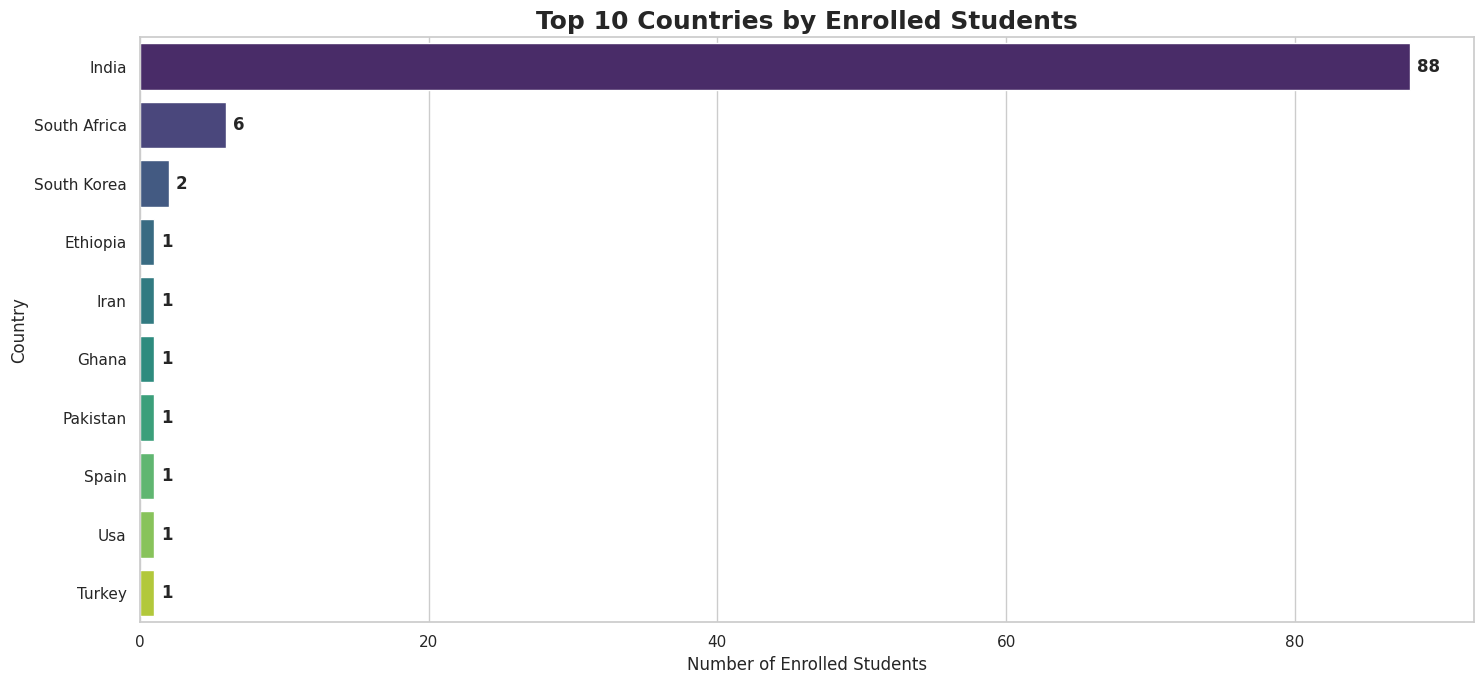

In [ ]:
top_10_country = country_targeting.sort_values(by='Enrolled_Students', ascending=False).head(10).reset_index()

plt.figure(figsize=(15, 7))
ax = sns.barplot(data=top_10_country, x='Enrolled_Students', y='Country', palette='viridis')

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width)}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=12, fontweight='bold',
                    xytext=(5, 0),
                    textcoords='offset points')

plt.title('Top 10 Countries by Enrolled Students', fontsize=18, fontweight='bold')
plt.xlabel('Number of Enrolled Students', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

## **Market Analysis**

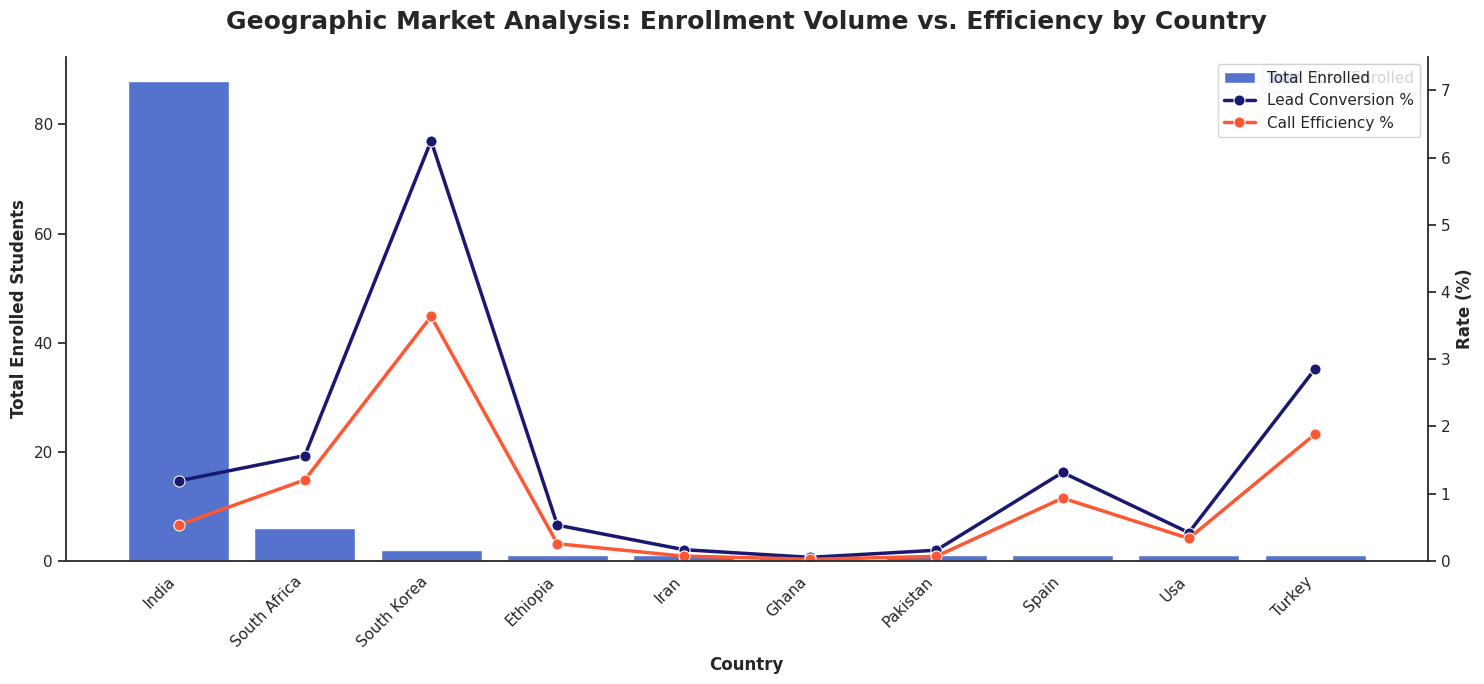

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data - Getting Top 10 Countries by Enrollment Volume
top_10_countries = country_targeting.sort_values(by='Enrolled_Students', ascending=False).head(10).reset_index()

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(15, 7))
sns.set_style("white") # Ensures no background grid

# --- PLOT 1: ENROLLED STUDENTS (Royal Blue Bars) ---
# Using 'Country' on x-axis now
sns.barplot(data=top_10_countries, x='Country', y='Enrolled_Students',
            color='#4169E1', ax=ax1, label='Total Enrolled')

ax1.set_ylabel('Total Enrolled Students', fontsize=12, fontweight='bold')
ax1.set_xlabel('Country', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# --- PLOT 2: PERFORMANCE RATES (Lines on Secondary Axis) ---
ax2 = ax1.twinx()

# Lead Conversion Rate (Midnight Blue)
sns.lineplot(data=top_10_countries, x='Country', y='Lead_Conversion_Rate',
             marker='o', markersize=8, linewidth=2.5, color='#191970',
             label='Lead Conversion %', ax=ax2)

# Call Efficiency Rate (Orange-Red)
sns.lineplot(data=top_10_countries, x='Country', y='Call_Efficiency_Rate',
             marker='o', markersize=8, linewidth=2.5, color='#FF5733',
             label='Call Efficiency %', ax=ax2)

# 3. Clean Up (Removing Grids and Spines for Minimalist Look)
ax2.set_ylabel('Rate (%)', fontsize=12, fontweight='bold')
sns.despine(right=False, top=True) # Remove top spine
ax1.grid(False) # Double check grid is off
ax2.grid(False)

# Auto-scaling Y-axis for the lines to make the 0.88 vs 0.59 gap visible
ymax_rate = top_10_countries[['Lead_Conversion_Rate', 'Call_Efficiency_Rate']].values.max()
ax2.set_ylim(0, ymax_rate * 1.2)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True)

plt.title('Geographic Market Analysis: Enrollment Volume vs. Efficiency by Country', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# **PART 5: Call Performance & Outreach Velocity Analysis**

---



Caller_Name
Rudra       34.91
Prajwal     21.83
Jyoti       13.56
Palak       12.47
Isha         5.16
Poppy        4.06
Shrutish     3.83
Shailja      3.53
Namrata      0.34
Twinkle      0.23
Pranjal      0.08
Mounika      0.00
Name: count, dtype: float64


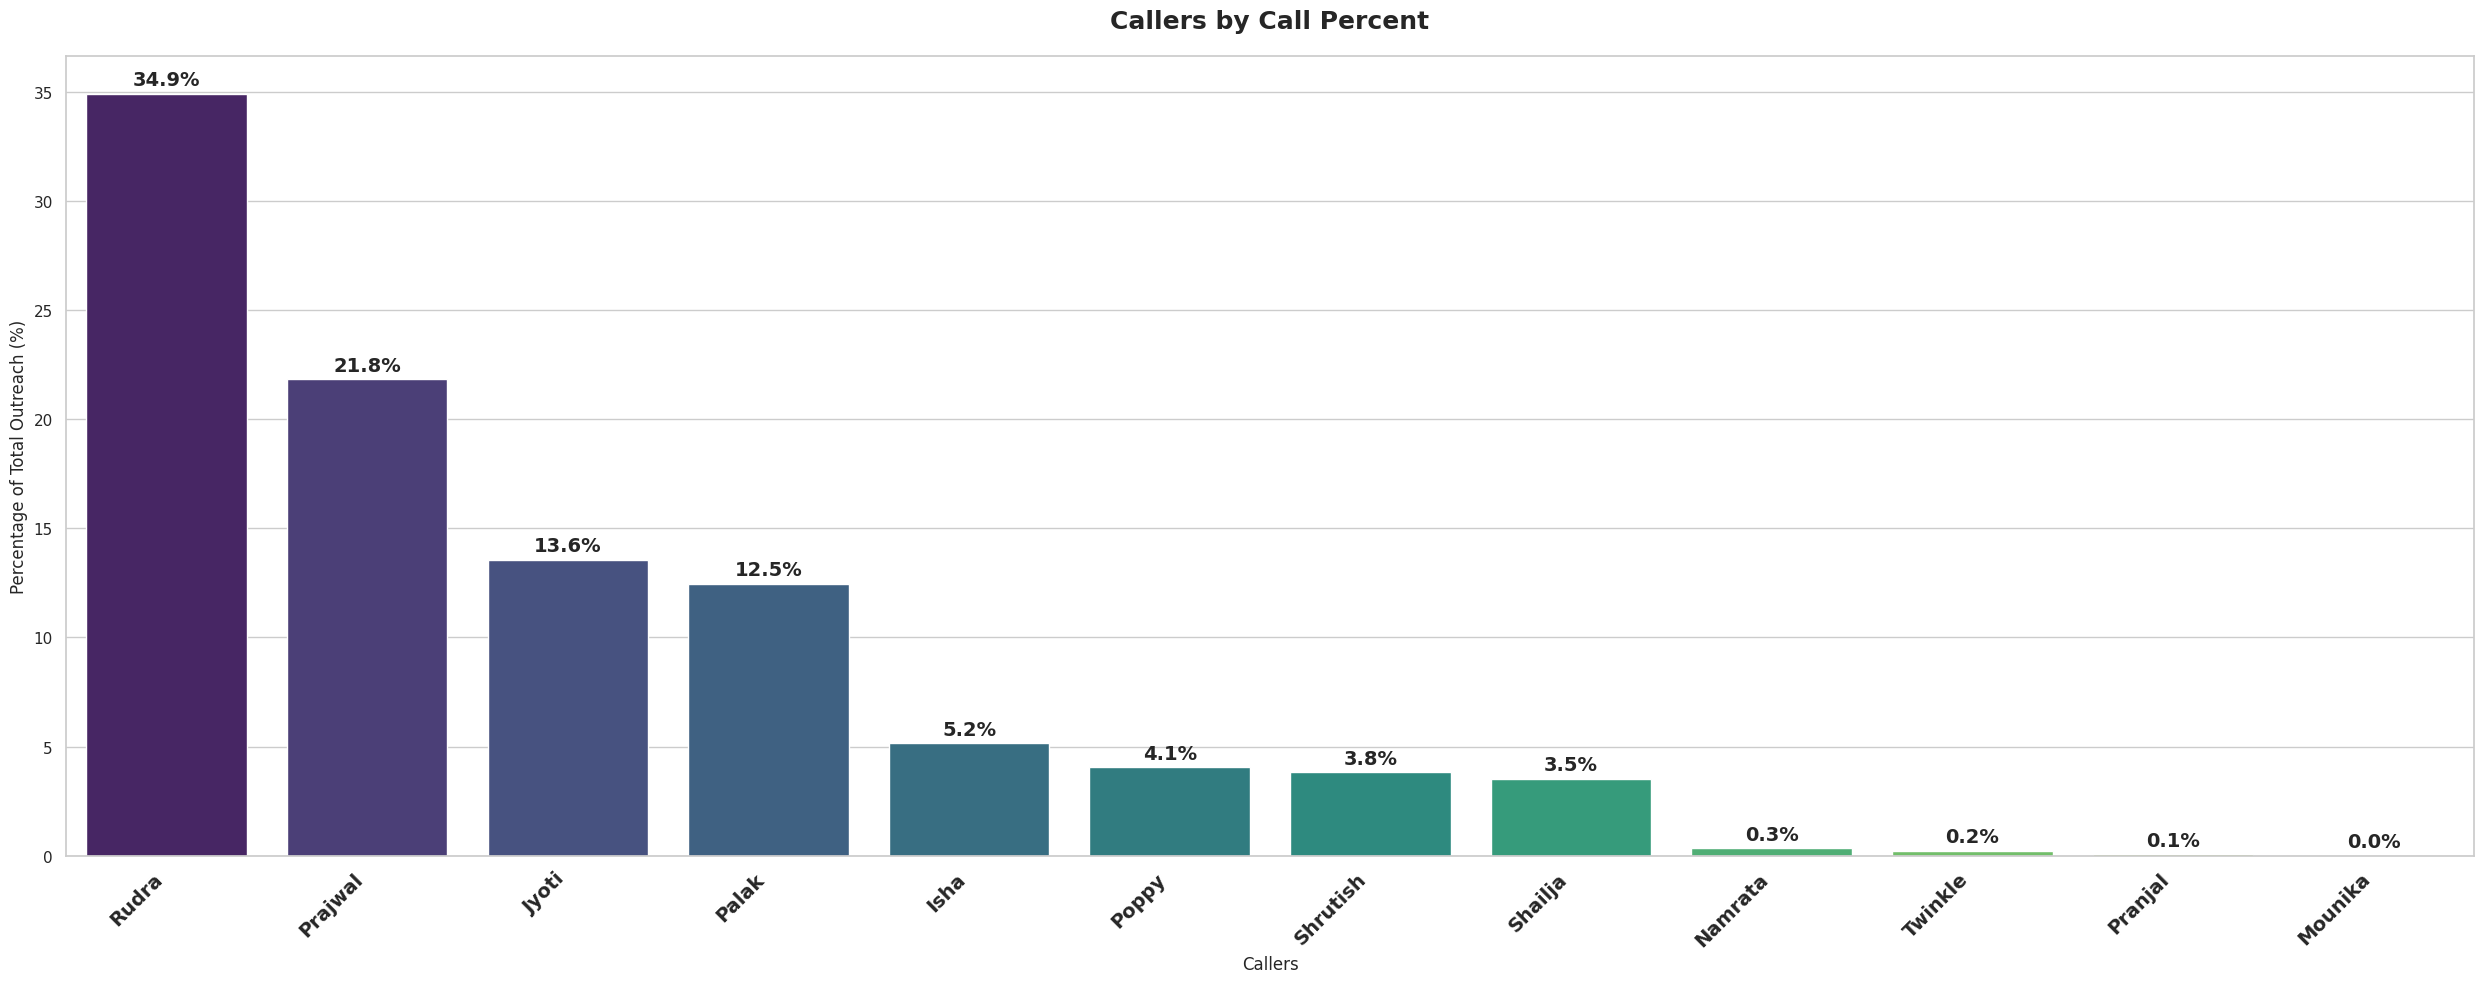

In [ ]:
callers = df['Caller_Name'].value_counts()
callers_count =((callers/len(df))*100).round(2)
print(callers_count)

######### CHART - Callers by Call Percent ###########
sns.set_theme(style='whitegrid')
plt.figure(figsize=(25,10))

ax = sns.barplot(data=callers_count.reset_index(), x='Caller_Name', y ='count', palette ='viridis', hue='Caller_Name', legend = False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                xytext=(0, 10),
                textcoords='offset points')

plt.title('Callers by Call Percent', fontsize = 18, fontweight = 'bold', pad=20 )
plt.xlabel('Callers')
plt.ylabel('Percentage of Total Outreach (%)')

plt.xticks(rotation=45,ha='right', fontsize='14', fontweight= 'bold')

plt.tight_layout()
plt.show()


## **Total Calls Made vs Unique Students**

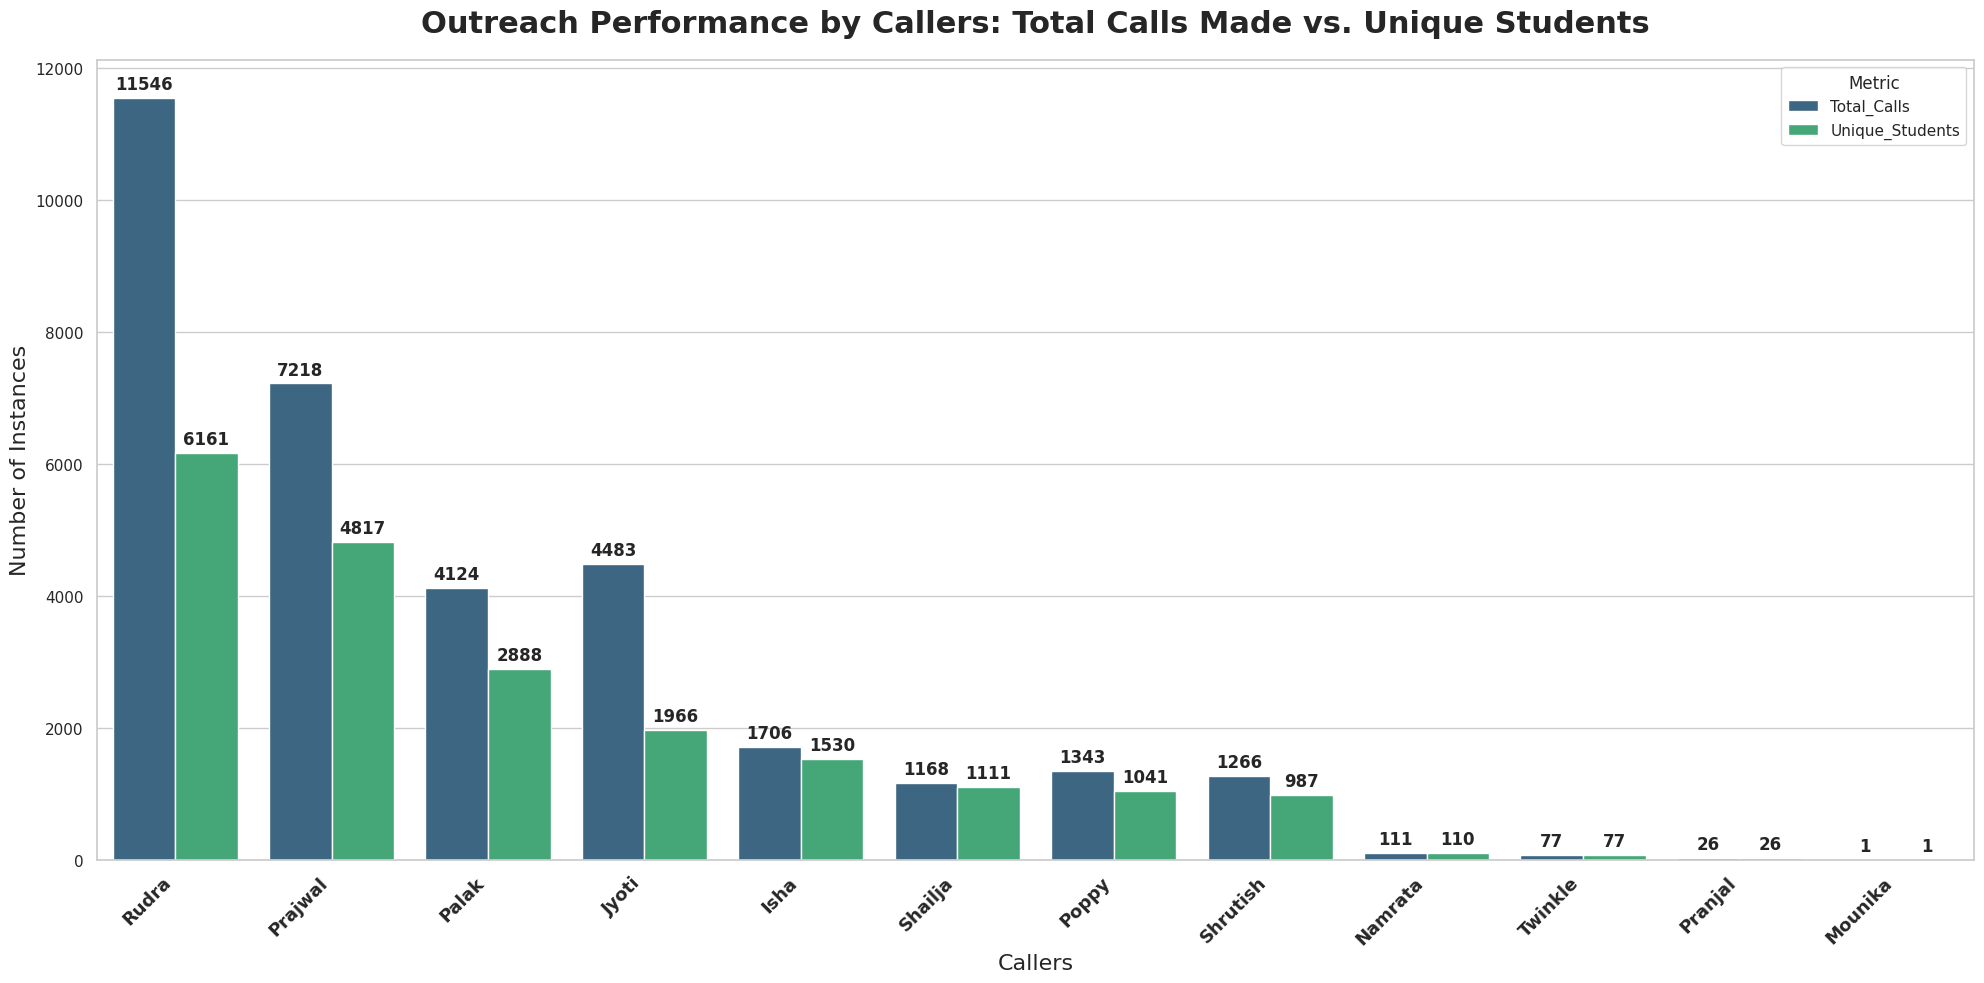

In [ ]:
# Group by Caller_Name to assess individual performance
caller_performance = df.groupby('Caller_Name').agg(
    Total_Calls=('App ID', 'count'),          # Volume of work
    Unique_Students=('App ID', 'nunique'),    # Reach (Number of leads handled)
    Enrolled_Students=('Remarks_Category', lambda x: (x == 'Enrolled').sum()),
    Unique_Enrolled_Students=('App ID', lambda x: df.loc[x.index, 'App ID'][df['Remarks_Category'] == 'Enrolled'].nunique())
)

plot_df = caller_performance.sort_values(by='Unique_Students', ascending=False).reset_index()

melted_df = plot_df.melt(id_vars='Caller_Name',
                         value_vars=['Total_Calls', 'Unique_Students'],
                         var_name='Metric',
                         value_name='Count')

plt.figure(figsize=(20, 10))
sns.set_theme(style='whitegrid')

ax = sns.barplot(data=melted_df, x='Caller_Name', y='Count', hue='Metric', palette='viridis')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 10),
                    textcoords='offset points')

plt.title('Outreach Performance by Callers: Total Calls Made vs. Unique Students', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Callers', fontsize=16)
plt.ylabel('Number of Instances', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## **2023 vs 2024 - Outreach & Enrollment**

## **Outreach**

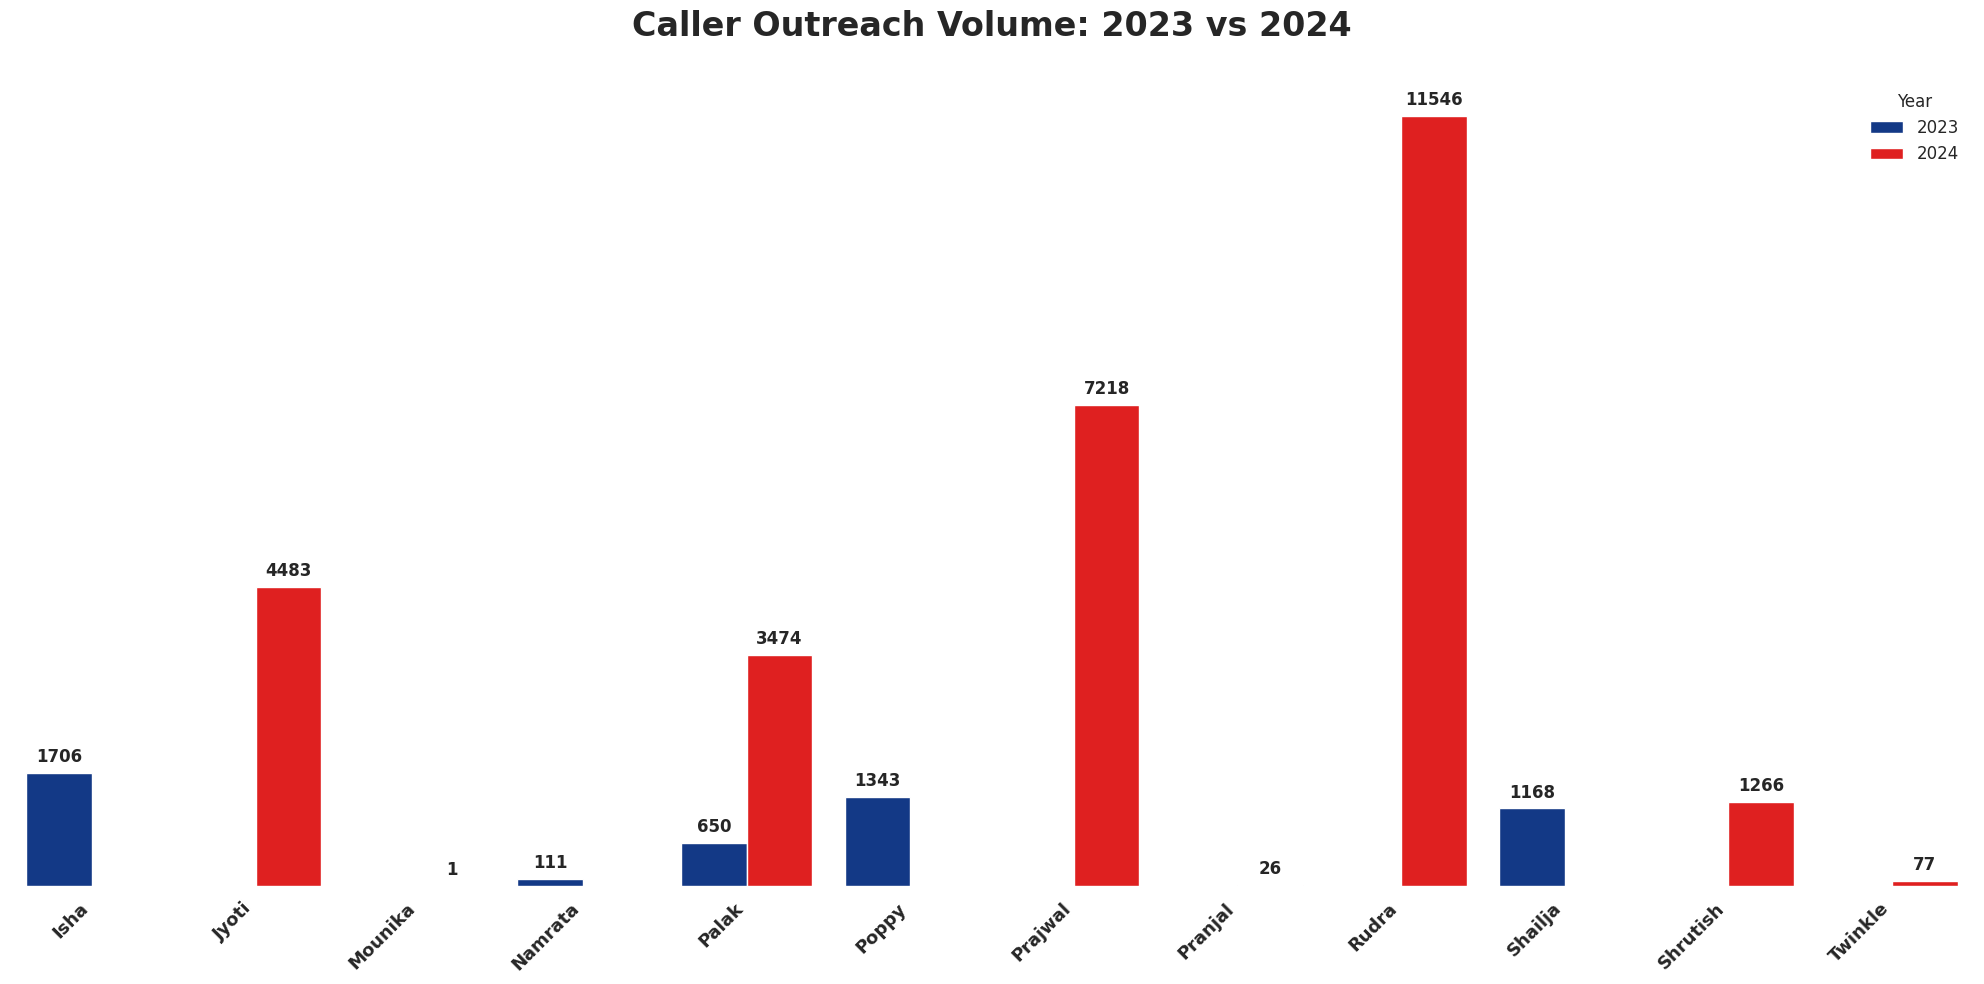

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data
df['Outreach_Call'] = pd.to_datetime(df['Outreach_Call'])
df['Year'] = df['Outreach_Call'].dt.year
df_filtered = df[df['Year'].isin([2023, 2024])]

# 2. Aggregate
outreach_perf = df_filtered.groupby(['Caller_Name', 'Year']).agg(
    Total_Calls=('App ID', 'count')
).reset_index()

# 3. Plotting with 'white' style
plt.figure(figsize=(20, 10))
sns.set_style("white")

# Define unique callers for precise x-axis positioning
callers = outreach_perf['Caller_Name'].unique()

ax = sns.barplot(
    data=outreach_perf,
    x='Caller_Name',
    y='Total_Calls',
    hue='Year',
    palette=['#003399', '#FF0000']
)

# 4. Annotate totals on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

# 5. REMOVE X AND Y AXIS LINES AND GRIDS
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')

# 6. EXACT ALIGNMENT FIX
# This ensures the names are centered under each cluster of bars
ax.set_xticks(range(len(callers)))
ax.set_xticklabels(callers, rotation=45, ha='right', fontsize=13, fontweight='bold')

# 7. Final Styling
plt.title('Caller Outreach Volume: 2023 vs 2024', fontsize=24, fontweight='bold', pad=30)
plt.legend(title='Year', frameon=False, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

## **Enrollment**

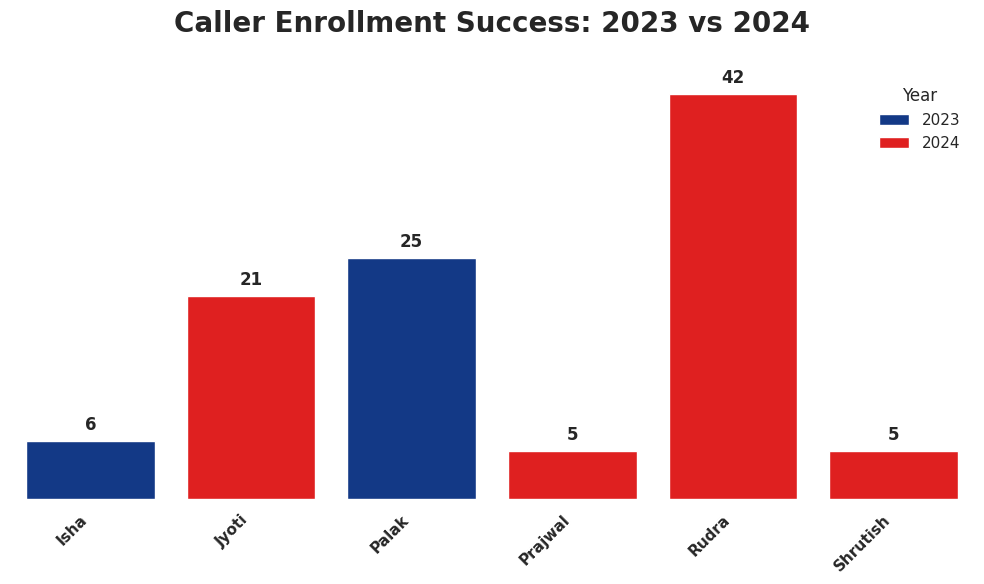

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation
# Filter for 'Enrolled' status and ensure years are correct
enrollment_df = df_filtered[df_filtered['Remarks_Category'] == 'Enrolled']

# Aggregate unique enrollments by Caller and Year
enroll_perf = enrollment_df.groupby(['Caller_Name', 'Year']).agg(
    Enrollments=('App ID', 'nunique')
).reset_index()

# 2. Plotting (Set style to 'white' to ensure no background grid)
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Using your specific colors: Blue (2023) and Red (2024)
ax = sns.barplot(
    data=enroll_perf,
    x='Caller_Name',
    y='Enrollments',
    hue='Year',
    palette=['#003399', '#FF0000']
)

# 3. Add Labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points')

# 4. REMOVE GRIDS, X-AXIS LINE, AND Y-AXIS LINE
sns.despine(left=True, bottom=True) # Removes the outer frame lines
ax.set_yticks([])                  # Removes Y-axis scale/numbers
ax.set_ylabel('')                  # Removes Y-axis title
ax.set_xlabel('')                  # Removes X-axis title

# 5. Styling
plt.title('Caller Enrollment Success: 2023 vs 2024', fontsize=20, fontweight='bold', pad=30)
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.legend(title='Year', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

## **Callers Performance**

In [ ]:
# Group by Caller_Name to assess individual performance
caller_performance = df.groupby('Caller_Name').agg(
    Total_Calls=('App ID', 'count'),          # Volume of work
    Unique_Students=('App ID', 'nunique'),    # Reach (Number of leads handled)
    Enrolled_Students=('Remarks_Category', lambda x: (x == 'Enrolled').sum()),
    Unique_Enrolled_Students=('App ID', lambda x: df.loc[x.index, 'App ID'][df['Remarks_Category'] == 'Enrolled'].nunique())
)

# Intensity Ratio (How many times does this caller follow up per lead?)
caller_performance['Intensity_Ratio'] = (caller_performance['Total_Calls'] / caller_performance['Unique_Students']).round(2)

# Lead Conversion Rate (Closing Power)
# How many of the unique students they spoke to actually enrolled?
caller_performance['Lead_Conversion_Rate'] = (caller_performance['Unique_Enrolled_Students'] / caller_performance['Unique_Students'] * 100).round(2)

# Call Efficiency Rate (Productivity)
# How many calls does it take them to get an enrollment?
caller_performance['Call_Efficiency_Rate'] = (caller_performance['Enrolled_Students'] / caller_performance['Total_Calls'] * 100).round(2)

final_report = caller_performance[caller_performance['Total_Calls'] > 1].sort_values(by='Lead_Conversion_Rate', ascending=False)
print(final_report)

             Total_Calls  Unique_Students  Enrolled_Students  \
Caller_Name                                                    
Jyoti               4483             1966                 21   
Palak               4124             2888                 25   
Rudra              11546             6161                 42   
Shrutish            1266              987                  5   
Isha                1706             1530                  6   
Prajwal             7218             4817                  5   
Namrata              111              110                  0   
Pranjal               26               26                  0   
Poppy               1343             1041                  0   
Shailja             1168             1111                  0   
Twinkle               77               77                  0   

             Unique_Enrolled_Students  Intensity_Ratio  Lead_Conversion_Rate  \
Caller_Name                                                                    
Jyoti  

## **BEST CALLERS**

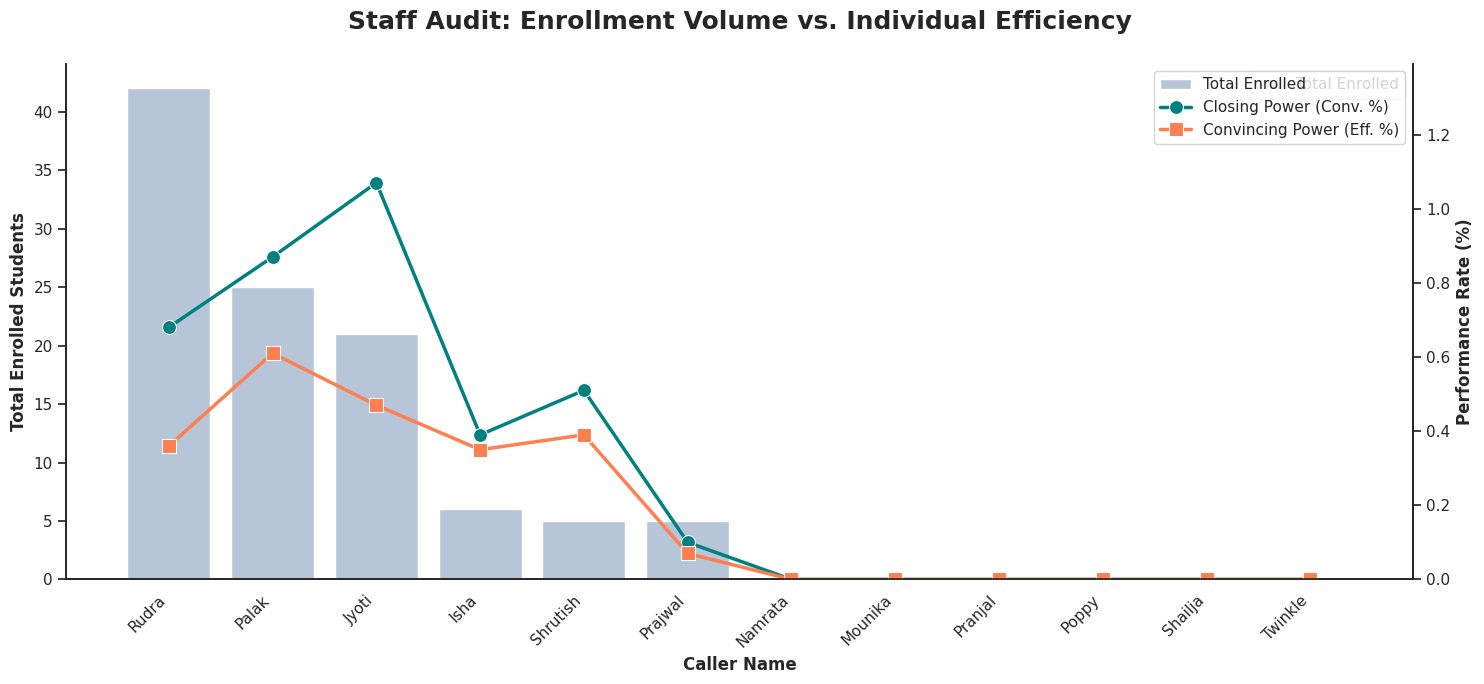

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
top_10_callers = caller_performance.sort_values(by='Enrolled_Students', ascending=False).reset_index()

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(15, 7))
sns.set_style("white")

# --- PLOT 1: ENROLLED STUDENTS (Light Silver/Gray Bars) ---
# Using a neutral color for bars makes the lines on top much easier to read
sns.barplot(data=top_10_callers, x='Caller_Name', y='Enrolled_Students',
            color='#B0C4DE', ax=ax1, label='Total Enrolled')

ax1.set_ylabel('Total Enrolled Students', fontsize=12, fontweight='bold')
ax1.set_xlabel('Caller Name', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# --- PLOT 2: PERFORMANCE RATES (Lines on Secondary Axis) ---
ax2 = ax1.twinx()

# Lead Conversion Rate (Teal)
sns.lineplot(data=top_10_callers, x='Caller_Name', y='Lead_Conversion_Rate',
             marker='o', markersize=10, linewidth=2.5, color='#008080',
             label='Closing Power (Conv. %)', ax=ax2)

# Call Efficiency Rate (Coral)
sns.lineplot(data=top_10_callers, x='Caller_Name', y='Call_Efficiency_Rate',
             marker='s', markersize=10, linewidth=2.5, color='#FF7F50',
             label='Convincing Power (Eff. %)', ax=ax2)

# 3. Clean Up
ax2.set_ylabel('Performance Rate (%)', fontsize=12, fontweight='bold')
sns.despine(right=False, top=True)
ax1.grid(False)
ax2.grid(False)

# Auto-zoom Y-axis
ymax_rate = top_10_callers[['Lead_Conversion_Rate', 'Call_Efficiency_Rate']].values.max()
ax2.set_ylim(0, ymax_rate * 1.3)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True)

plt.title('Staff Audit: Enrollment Volume vs. Individual Efficiency', fontsize=18, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

## **A Deep Dive into Caller Efficiency & Lead**

In [ ]:
# Grouping to see who is escalating the most
caller_performance = df.groupby('Caller_Name')['Escalation_Required'].value_counts(normalize=True).unstack().fillna(0) * 100
Enrolled_Students = df.groupby('Caller_Name')['Remarks_Category'].apply(lambda x: (x == 'Enrolled').sum())
caller_performance['Total_Enrollments'] = Enrolled_Students
# Focus on the 'Yes' percentage (Escalation Rate)
caller_performance = caller_performance.sort_values(by='Total_Enrollments', ascending=False)
print("--- Caller Performance: Escalation vs. Enrollment ---")
print(caller_performance[['Yes', 'No', 'Total_Enrollments']].round(2))


--- Caller Performance: Escalation vs. Enrollment ---
Escalation_Required   Yes      No  Total_Enrollments
Caller_Name                                         
Rudra                1.96   98.04                 42
Palak                2.96   97.04                 25
Jyoti                0.74   99.26                 21
Isha                 1.41   98.59                  6
Shrutish             2.45   97.55                  5
Prajwal              3.56   96.44                  5
Namrata              0.00  100.00                  0
Mounika              0.00  100.00                  0
Pranjal              7.69   92.31                  0
Poppy                1.64   98.36                  0
Shailja              2.57   97.43                  0
Twinkle              1.30   98.70                  0


### **Total Enrollments vs Escalation Rate**

/tmp/ipython-input-511/4095507834.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Caller_Name', y='Total_Enrollments', palette='Blues_r', ax=ax1)
/tmp/ipython-input-511/4095507834.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


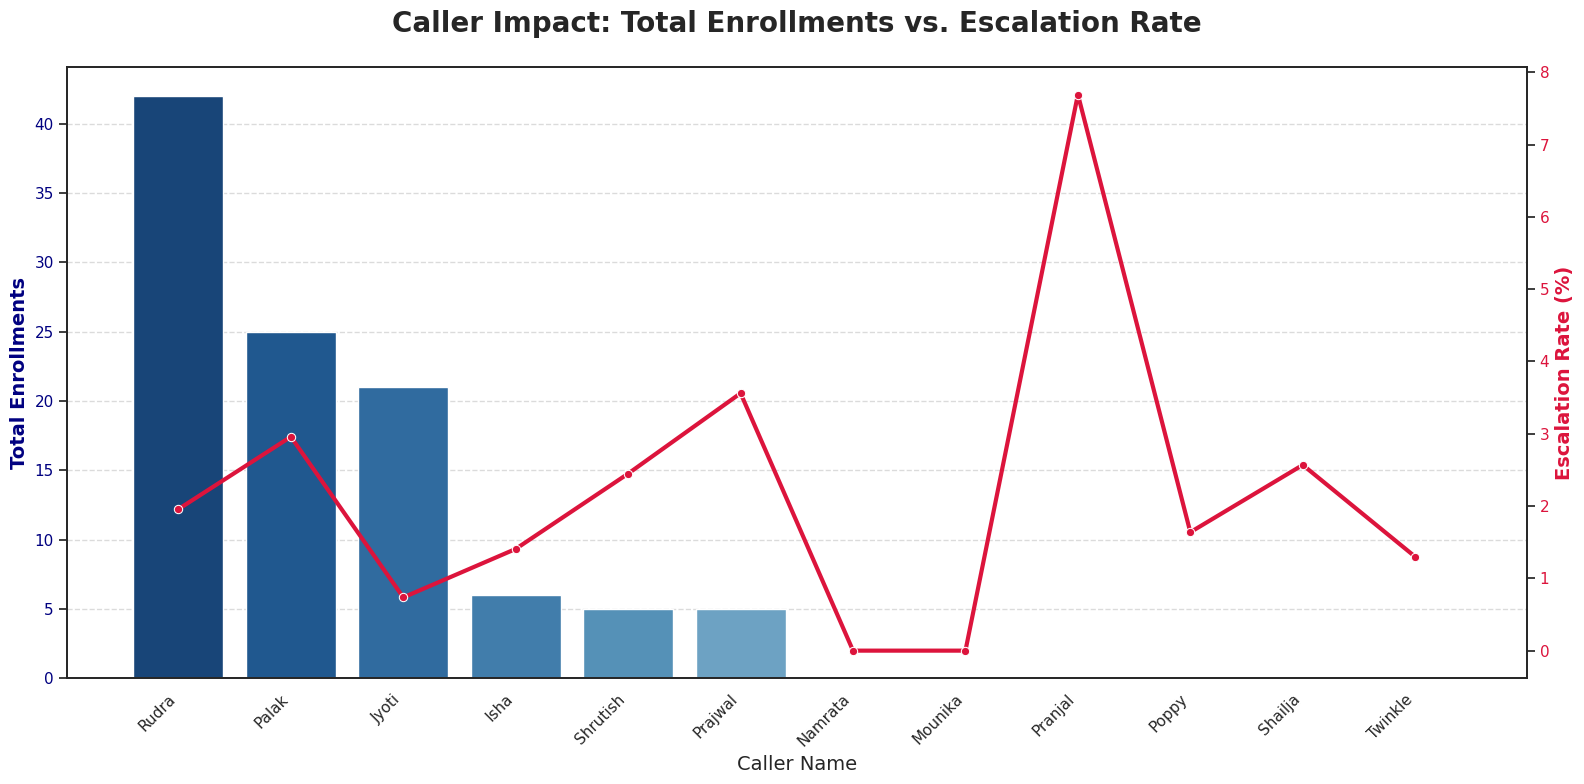

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plot_data = caller_performance.reset_index()


fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_theme(style='white')

# Create the Bar Chart (Primary Axis: Enrollments)
sns.barplot(data=plot_data, x='Caller_Name', y='Total_Enrollments', palette='Blues_r', ax=ax1)
ax1.set_ylabel('Total Enrollments', fontsize=14, fontweight='bold', color='navy')
ax1.set_xlabel('Caller Name', fontsize=14)
ax1.tick_params(axis='y', labelcolor='navy')

# Create the Line Chart (Secondary Axis: Escalation %)
ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x='Caller_Name', y='Yes', color='crimson', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Escalation Rate (%)', fontsize=14, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')


plt.title('Caller Impact: Total Enrollments vs. Escalation Rate', fontsize=20, fontweight='bold', pad=25)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Deeper Analysis Using Remarks Category**

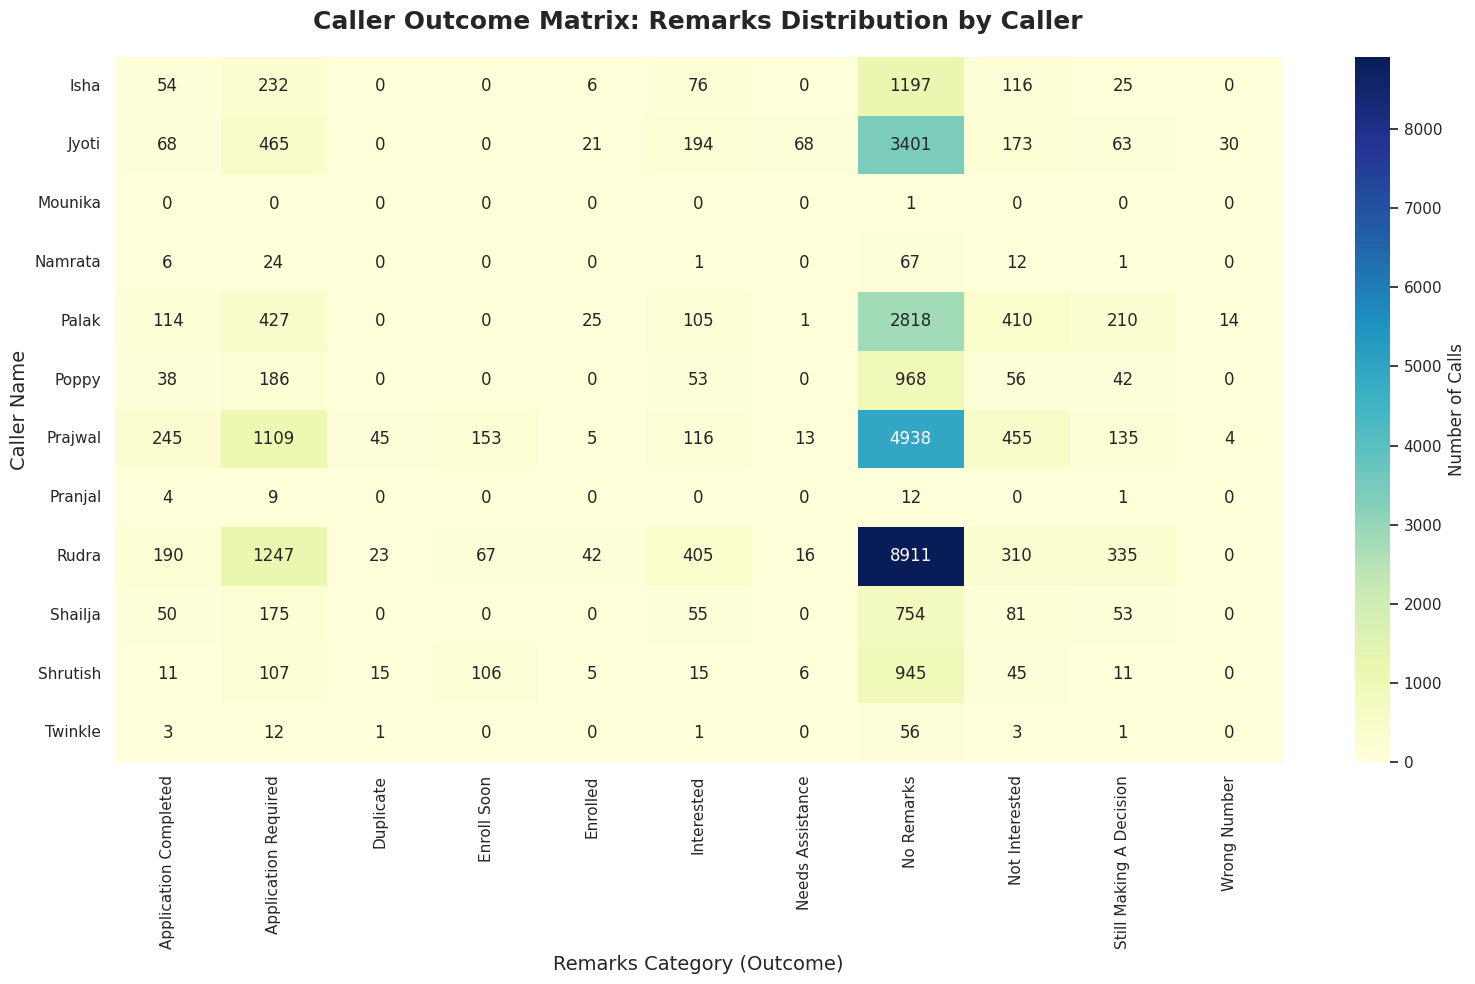

In [ ]:
# Pivot Table (Frequency of each Remark per Caller)
heatmap_data = df.groupby(['Caller_Name', 'Remarks_Category']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(16, 10))
sns.set_theme(style='white')

# Using 'annot=True' to show the actual numbers in the squares
ax = sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Calls'})

# Formatting
plt.title('Caller Outcome Matrix: Remarks Distribution by Caller', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Remarks Category (Outcome)', fontsize=14)
plt.ylabel('Caller Name', fontsize=14)

plt.tight_layout()
plt.show()

## **First Contact Conversion Efficiency**

In [ ]:
first_attempts = df.groupby('App ID').head(1)

first_contact_enrollments = (first_attempts['Remarks_Category'] == 'Enrolled').sum()

total_unique_students = df['App ID'].nunique()

first_contact_conversion = (first_contact_enrollments / total_unique_students) * 100

print(f"Total Unique Applicants: {total_unique_students}")
print(f"Enrolled on First Attempt: {first_contact_enrollments}")
print(f"First Contact Conversion Rate: {first_contact_conversion:.2f}%")

Total Unique Applicants: 15114
Enrolled on First Attempt: 63
First Contact Conversion Rate: 0.42%


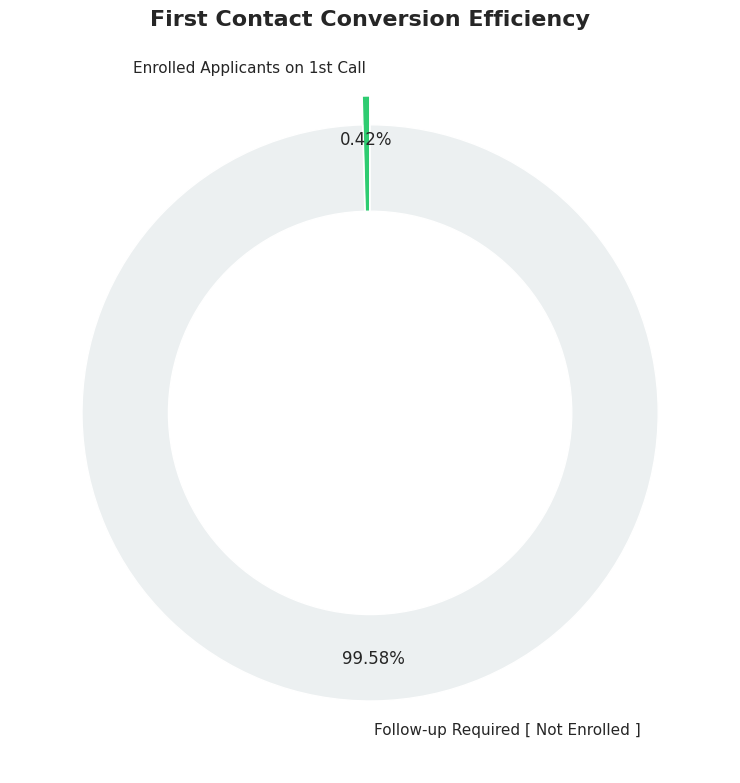

In [ ]:
enrolled = first_contact_enrollments
not_enrolled_yet = total_unique_students - first_contact_enrollments
data = [enrolled, not_enrolled_yet]
labels = ['Enrolled Applicants on 1st Call', 'Follow-up Required [ Not Enrolled ]']
colors = ['#2ecc71', '#ecf0f1'] # Green for success, Light Grey for the rest

plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.2f%%', startangle=90,
        colors=colors, pctdistance=0.85, explode=(0.1, 0))


centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('First Contact Conversion Efficiency', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()